# Unified Differentiable ABM: 36 Calibrated Thinking + 100 Momentum + 100 Value + 64 Random Agents

This notebook integrates the complete unified population of **300 agents**:
- **36 Investor/Thinking Agents** (12 base neural network models from `checkpoint_6` $\times$ 3 risk bands: `low`, `mid`, `high`)
- **100 Momentum Agents** (with independently calibrated momentum sensitivities)
- **100 Value Agents** (with independently calibrated value sensitivities)
- **64 Random Agents** (providing bounded background noise order flow)

### Market Mechanism:
- Uses the **Direct Demand Price Impact Approach** ($P_{t+1} = P_t + \eta \bar{D}_t + \epsilon_t$), where aggregate normalized demand shifts the clearing market price.
- Personality parameters (`risk`, `fear`, `boldness`, `range_stock`) are seamlessly integrated from `calibrated_personalities.json`.

In [49]:
# ============================================================
# CELL 0 — Imports, configuration, reproducibility and Setup
# ============================================================
import os
import math
import random
import json
import warnings
from pathlib import Path
from collections import deque
from dataclasses import dataclass, field
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

# ---------- EDIT THESE ----------
DATA_PATH = r'D:\archive\ADANIPORTS.csv'
CHECKPOINT_DIR = r'C:\Users\user\.vscode\abms\files\checkpoint_6'

# 12 existing thinking-agent checkpoints & risk bands (12 x 3 = 36 thinking agents)
BATCH_IDX = 1
HORIZONS = (15, 30, 45)
AGENT_LOOKBACK = {'lstm': 120, 'gru': 60, 'cnn': 30, 'mlp': 45}
MAX_THINKING_LOOKBACK = max(AGENT_LOOKBACK.values())  # 120
THINKING_LOOKBACK = MAX_THINKING_LOOKBACK

RISK_BANDS = [('low', 0.0, 0.3), ('mid', 0.3, 0.6), ('high', 0.6, 1.0)]
N_INVESTOR_BASE = 12
N_INVESTORS = N_INVESTOR_BASE * len(RISK_BANDS)   # = 36

# Requested ABM population (Total = 36 + 100 + 100 + 64 = 300)
N_MOMENTUM = 100
N_VALUE = 100
N_RANDOM = 64
N_TOTAL = N_INVESTORS + N_MOMENTUM + N_VALUE + N_RANDOM

# ---------- MARKET EXECUTION CONFIGURATION ----------
DELTA_MAX = 0.05
TICK_SIZE = 0.05
URGENCY_MARKET_THRESHOLD = 0.8
ORDER_TTL = 5
BOOK_SEED_ORDERS = 10
BOOK_SEED_WIDTH = 0.02
USE_LOB = False   # False = direct demand impact equation (normal approach); True = Limit Order Book matching

# ---------- CALIBRATED PERSONALITY CONFIGURATION ----------
CALIBRATED_PARAMS_PATH = r'C:\Users\user\.vscode\abms\files\calibrated_personalities.json'
USE_CALIBRATED_PARAMS = True   # True = load from json; False = random draws

CALIBRATED = {}
CALIBRATED_BY_KEY = {}   # (checkpoint_id, band) -> params
if USE_CALIBRATED_PARAMS and os.path.exists(CALIBRATED_PARAMS_PATH):
    try:
        with open(CALIBRATED_PARAMS_PATH, 'r', encoding='utf-8') as f:
            _data = json.load(f)
        for a in _data.get('agents', []):
            CALIBRATED[a['id']] = a
            if 'checkpoint_id' in a and 'band' in a:
                CALIBRATED_BY_KEY[(a['checkpoint_id'], a['band'])] = a
        print(f'Loaded calibrated params for {len(CALIBRATED)}/{len(_data.get("agents", []))} agents')
    except Exception as e:
        print(f'Notice: Failed to read calibrated params ({e}), falling back to random init.')
else:
    print('Using random personality parameters (calibrated file not loaded).')

# TEST 1:
# Every simulation agent starts at its comfortable risk allocation.
INITIALIZE_AT_RISK = True

# ------------------------------------------------------------
# ABM training
# ------------------------------------------------------------
ABM_SEQUENCE_LENGTH = 500
ABM_EPOCHS = 300
ABM_LR = 1e-2
ABM_WARM_UP = 120

# ------------------------------------------------------------
# Regularization
# ------------------------------------------------------------
GRAD_CLIP_NORM = 1.0
SENSITIVITY_CLIP = 5.0

# ------------------------------------------------------------
# Demand / simulation scales
# ------------------------------------------------------------
FORECAST_TANH_SCALE = 0.5
THINKING_DEMAND_SCALE = 7.5
RANDOM_TRAIN_ACTION_SCALE = 0.5

STARTING_CASH = 1_000_000.0
E_SCALE = 1.5
DROPOUT_RATE = 0.50
N_SIMULATIONS = 5   # number of independent ABM replay runs
NEIGHBOR_CHOICES = (4, 5)
MAX_SIM_ETA = 1.0

OUTPUT_DIR = os.path.join(
    CHECKPOINT_DIR,
    'unified_abm_v2_independent_mv'
)
MV_AGENT_DIR = os.path.join(OUTPUT_DIR, 'mv_agents')
os.makedirs(MV_AGENT_DIR, exist_ok=True)

print('Data:', DATA_PATH)
print('Checkpoint:', CHECKPOINT_DIR)
print('Output:', OUTPUT_DIR)
print(f'Population: {N_INVESTORS} thinking (12x3 risk bands) + {N_MOMENTUM} momentum + {N_VALUE} value + {N_RANDOM} random = {N_TOTAL} total')
print(f'Thinking Lookbacks: {AGENT_LOOKBACK} (Max = {MAX_THINKING_LOOKBACK} days)')
print('Risk Bands:', RISK_BANDS)
print('LOB Enabled:', USE_LOB)
print('Calibrated Params Enabled:', USE_CALIBRATED_PARAMS)


Device: cpu
Loaded calibrated params for 300/300 agents
Data: D:\archive\ADANIPORTS.csv
Checkpoint: C:\Users\user\.vscode\abms\files\checkpoint_6
Output: C:\Users\user\.vscode\abms\files\checkpoint_6\unified_abm_v2_independent_mv
Population: 36 thinking (12x3 risk bands) + 100 momentum + 100 value + 64 random = 300 total
Thinking Lookbacks: {'lstm': 120, 'gru': 60, 'cnn': 30, 'mlp': 45} (Max = 120 days)
Risk Bands: [('low', 0.0, 0.3), ('mid', 0.3, 0.6), ('high', 0.6, 1.0)]
LOB Enabled: False
Calibrated Params Enabled: True


In [50]:
# ============================================================
# CELL 1 — Feature construction used by the 12 frozen agents
# ============================================================

TS_FEATURES = [
    "close_norm",
    "daily_return",
    "volume_norm",
    "vwap_distance",
    "volatility",
    "ma20_distance",
]

MLP_FEATURES = [
    "close_norm",
    "daily_return",
    "volume_norm",
    "vwap_distance",
    "momentum_15",
    "momentum_30",
    "momentum_60",
    "volatility_15",
    "volatility_30",
    "volatility_60",
]

def prepare_market_data(path):
    df = pd.read_csv(path)

    required = ["Close", "Volume", "VWAP", "Prev Close"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    if "Date" in df.columns:
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date")

    df = df.reset_index(drop=True).copy()

    df["daily_return"] = (df["Close"] - df["Prev Close"]) / (df["Prev Close"] + 1e-12)
    df["MA20"] = df["Close"].rolling(20).mean()
    df["volatility"] = df["daily_return"].rolling(20).std()
    df["vwap_distance"] = (df["Close"] - df["VWAP"]) / (df["VWAP"] + 1e-12)
    df["ma20_distance"] = (df["Close"] - df["MA20"]) / (df["MA20"] + 1e-12)

    for n in (15, 30, 60):
        df[f"momentum_{n}"] = (
            (df["Close"] - df["Close"].shift(n))
            / (df["Close"].shift(n) + 1e-12)
        )
        df[f"volatility_{n}"] = df["daily_return"].rolling(n).std()

    df["log_volume"] = np.log1p(df["Volume"])

    # Same future-return construction used by the original training notebook.
    future_return = np.full(len(df), np.nan, dtype=np.float64)
    close = df["Close"].to_numpy(dtype=np.float64)
    for i in range(len(df) - 45):
        base = close[i]
        future_return[i] = sum(
            (close[i + j] - base) / (base + 1e-12)
            for j in range(1, 46)
        )
    df["future_return"] = future_return

    df = df.dropna().reset_index(drop=True)

    close_mean, close_std = df["Close"].mean(), df["Close"].std()
    vol_mean, vol_std = df["log_volume"].mean(), df["log_volume"].std()

    df["close_norm"] = (df["Close"] - close_mean) / (close_std + 1e-8)
    df["volume_norm"] = (df["log_volume"] - vol_mean) / (vol_std + 1e-8)

    return df

MARKET_DF = prepare_market_data(DATA_PATH)
print("Market rows:", len(MARKET_DF))
print(MARKET_DF[["Close", "daily_return", "volatility"]].head())


Market rows: 2411
    Close  daily_return  volatility
0  164.00      0.015794    0.022445
1  161.25     -0.016768    0.020812
2  161.05     -0.001240    0.020709
3  159.85     -0.007451    0.020553
4  157.25     -0.016265    0.020210


In [51]:
# ============================================================
# CELL 2 — Exact architectures of the 12 existing checkpoints
# ============================================================

class LSTMReturnPredictor(nn.Module):
    def __init__(self, input_size=6, hidden_size=128, num_layers=4, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size, hidden_size, num_layers,
            dropout=dropout, batch_first=True
        )
        self.fc1 = nn.Linear(hidden_size, 64)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        x = self.fc1(hidden[-1])
        x = self.gelu(x)
        x = self.dropout(x)
        return self.fc2(x)


class GRUReturnPredictor(nn.Module):
    def __init__(self, input_size=6, hidden_size=128, num_layers=4, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(
            input_size, hidden_size, num_layers,
            dropout=dropout, batch_first=True
        )
        self.fc1 = nn.Linear(hidden_size, 64)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        _, hidden = self.gru(x)
        x = self.fc1(hidden[-1])
        x = self.gelu(x)
        x = self.dropout(x)
        return self.fc2(x)


class CNNReturnPredictor(nn.Module):
    def __init__(self, input_size=6, hidden_size=64, num_layers=2, dropout=0.5):
        super().__init__()
        channels = [input_size] + [hidden_size] * num_layers
        blocks = []
        for i in range(num_layers):
            blocks += [
                nn.Conv1d(channels[i], channels[i+1], 3, padding=1),
                nn.GroupNorm(8, channels[i+1]),
                nn.GELU(),
                nn.Dropout(dropout),
            ]
        self.conv = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(hidden_size, 64)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.conv(x.permute(0, 2, 1))
        x = self.pool(x).squeeze(-1)
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.dropout(x)
        return self.fc2(x)


class MLPReturnPredictor(nn.Module):
    def __init__(self, input_size=10, hidden_size=64, dropout=0.4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_size, hidden_size // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden_size // 2, 1),
        )

    def forward(self, x):
        return self.net(x.mean(dim=1))


AGENT_CLASS = {
    "lstm": LSTMReturnPredictor,
    "gru": GRUReturnPredictor,
    "cnn": CNNReturnPredictor,
    "mlp": MLPReturnPredictor,
}

AGENT_HPARAMS = {
    "lstm": dict(hidden_size=128, num_layers=4, dropout=0.3),
    "gru": dict(hidden_size=128, num_layers=4, dropout=0.3),
    "cnn": dict(hidden_size=64, num_layers=2, dropout=0.5),
    "mlp": dict(hidden_size=64, dropout=0.4),
}

AGENT_LOOKBACK = {"lstm": 120, "gru": 60, "cnn": 30, "mlp": 60}
AGENT_FEATKEY = {
    "lstm": "ts", "gru": "ts", "cnn": "ts", "mlp": "mlp"
}


In [52]:
# ============================================================
# CELL 3 — Load and freeze the 12 base checkpoints (36 thinking agents)
# ============================================================
def load_checkpoint(path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    if 'model_state_dict' in ckpt:
        return ckpt['model_state_dict']
    return ckpt

BASE_12_CHECKPOINTS = []

for atype in ['lstm', 'gru', 'cnn', 'mlp']:
    lb = AGENT_LOOKBACK[atype]  # lstm: 120, gru: 60, cnn: 30, mlp: 45
    for horizon in HORIZONS:
        candidates = [
            os.path.join(CHECKPOINT_DIR, f'agent_{atype}_batch_{BATCH_IDX}_{horizon}.pt'),
            os.path.join(CHECKPOINT_DIR, f'agent_{atype}_batch_{BATCH_IDX}_{horizon}.pth'),
            os.path.join(CHECKPOINT_DIR, f'best_{atype}_return_model_{horizon}.pt'),
            os.path.join(CHECKPOINT_DIR, f'best_{atype}_return_model_{horizon}.pth'),
            os.path.join(os.path.dirname(CHECKPOINT_DIR), f'best_{atype}_return_model_{horizon}.pt'),
        ]
        fpath = None
        for cand in candidates:
            if os.path.exists(cand):
                fpath = cand
                break

        if atype == 'lstm':
            model = LSTMReturnPredictor().to(DEVICE)
        elif atype == 'gru':
            model = GRUReturnPredictor().to(DEVICE)
        elif atype == 'cnn':
            model = CNNReturnPredictor().to(DEVICE)
        elif atype == 'mlp':
            model = MLPReturnPredictor(input_size=10, hidden_size=64).to(DEVICE)

        if fpath is not None:
            try:
                model.load_state_dict(load_checkpoint(fpath), strict=True)
                print(f'Successfully loaded {atype.upper()}-{horizon} (lookback={lb}) from {fpath}')
            except Exception as e:
                print(f'Warning loading {fpath}: {e}')
                model.load_state_dict(load_checkpoint(fpath), strict=False)
        else:
            print(f'Notice: Checkpoint for {atype}-{horizon} not found, using initialized weights.')

        model.eval()
        for param in model.parameters():
            param.requires_grad = False

        BASE_12_CHECKPOINTS.append({
            'type': atype,
            'horizon': horizon,
            'lookback': lb,
            'features_key': 'mlp' if atype == 'mlp' else 'ts',
            'model': model,
            'path': fpath,
        })

# Expand 12 base checkpoints to 36 Thinking Agents across 3 Risk Bands
THINKING_POPULATION = []
for base_id, base in enumerate(BASE_12_CHECKPOINTS):
    for band_name, lo, hi in RISK_BANDS:
        THINKING_POPULATION.append({
            **base,
            'band': band_name,
            'checkpoint_id': base_id,
            'risk_bounds': (lo, hi),
        })

print('Loaded base checkpoints:', len(BASE_12_CHECKPOINTS))
print('Expanded thinking population:', len(THINKING_POPULATION), 'agents across risk bands [low, mid, high]')
MAX_THINKING_LOOKBACK = max(a['lookback'] for a in THINKING_POPULATION)
THINKING_LOOKBACK = MAX_THINKING_LOOKBACK
print('Max thinking lookback:', MAX_THINKING_LOOKBACK, 'days')


Successfully loaded LSTM-15 (lookback=120) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_lstm_batch_1_15.pt
Successfully loaded LSTM-30 (lookback=120) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_lstm_batch_1_30.pt
Successfully loaded LSTM-45 (lookback=120) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_lstm_batch_1_45.pt
Successfully loaded GRU-15 (lookback=60) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_gru_batch_1_15.pt
Successfully loaded GRU-30 (lookback=60) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_gru_batch_1_30.pt
Successfully loaded GRU-45 (lookback=60) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_gru_batch_1_45.pt
Successfully loaded CNN-15 (lookback=30) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_cnn_batch_1_15.pt
Successfully loaded CNN-30 (lookback=30) from C:\Users\user\.vscode\abms\files\checkpoint_6\agent_cnn_batch_1_30.pt
Successfully loaded CNN-45 (lookback=30) from C:\Users\user\.vs

In [53]:
# # ============================================================
# # CELL 4 — Build frozen thinking-agent demand series
# # ============================================================
# #
# # IMPORTANT:
# # The aggregate thinking demand is computed only for diagnostics /
# # final analysis. It is NOT passed into MV training.
# #
# # The final simulation uses the 12 thinking agents individually,
# # so their actions are not double-counted.

# def build_feature_matrices(df):
#     return {
#         "ts": df[TS_FEATURES].to_numpy(dtype=np.float32),
#         "mlp": df[MLP_FEATURES].to_numpy(dtype=np.float32),
#     }

# FEATURE_MATS = build_feature_matrices(MARKET_DF)
# MAX_THINKING_LOOKBACK = max(
#     a["lookback"] for a in THINKING_POPULATION
# )

# def build_thinking_demand_series(df, population):
#     mats = build_feature_matrices(df)
#     n = len(df)
#     demand = np.zeros(n, dtype=np.float32)

#     with torch.no_grad():
#         for t in range(MAX_THINKING_LOOKBACK - 1, n):
#             signals = []

#             for a in population:
#                 lb = a["lookback"]
#                 window = mats[a["features_key"]][t-lb+1:t+1]

#                 x = torch.tensor(
#                     window,
#                     dtype=torch.float32,
#                     device=DEVICE
#                 ).unsqueeze(0)

#                 raw = float(a["model"](x).item())
#                 signals.append(
#                     math.tanh(raw * FORECAST_TANH_SCALE)
#                 )

#             demand[t] = THINKING_DEMAND_SCALE * float(
#                 np.mean(signals)
#             )

#     demand[:MAX_THINKING_LOOKBACK-1] = (
#         demand[MAX_THINKING_LOOKBACK-1]
#     )

#     return demand

# THINKING_DEMAND = build_thinking_demand_series(
#     MARKET_DF,
#     THINKING_POPULATION
# )

# print("Thinking-demand shape:", THINKING_DEMAND.shape)
# print(
#     "Thinking-demand range:",
#     THINKING_DEMAND.min(),
#     THINKING_DEMAND.max()
# )

# plt.figure(figsize=(12, 4))
# plt.plot(THINKING_DEMAND)
# plt.title("Frozen 12-Agent Aggregate Demand — Diagnostic Only")
# plt.xlabel("Day")
# plt.ylabel("Demand")
# plt.grid(alpha=0.3)
# plt.show()


Momentum mean/std: 0.0033089453 0.9742356
Value mean/std   : -0.0038988357 0.97966653


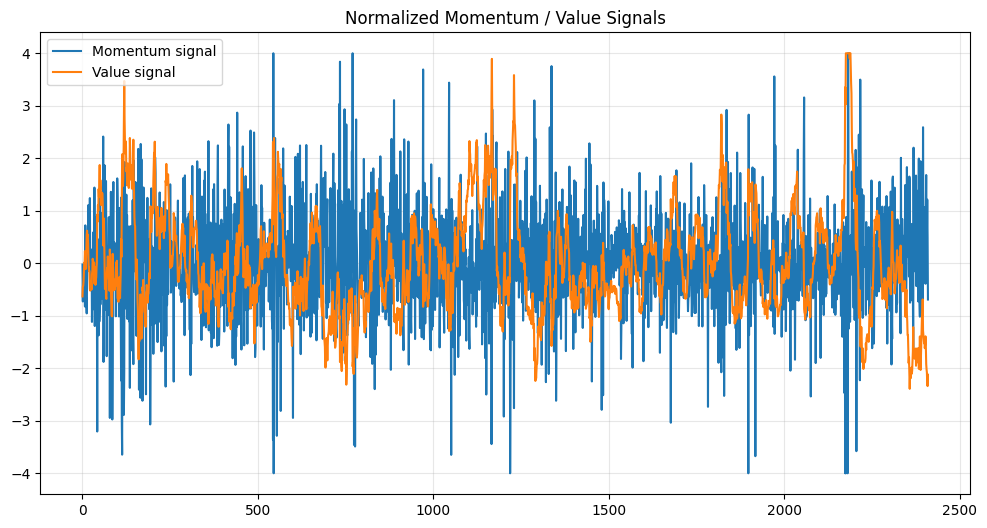

In [54]:
# ============================================================
# CELL 5 — Momentum/value signals
# ============================================================

def zscore_clip(x, clip=4.0):
    x = np.asarray(x, dtype=np.float32)
    mean = float(np.nanmean(x))
    std = float(np.nanstd(x) + 1e-8)
    z = (x - mean) / std
    z = np.clip(z, -clip, clip)
    return z.astype(np.float32), {"mean": mean, "std": std, "clip": clip}

close = MARKET_DF["Close"].to_numpy(dtype=np.float64)

log_return = np.zeros(len(close), dtype=np.float64)
log_return[1:] = np.log((close[1:] + 1e-12) / (close[:-1] + 1e-12))

if "Fundamental" not in MARKET_DF.columns:
    MARKET_DF["Fundamental"] = MARKET_DF["Close"].rolling(50).mean()
    MARKET_DF["Fundamental"] = MARKET_DF["Fundamental"].bfill()

fundamental = MARKET_DF["Fundamental"].to_numpy(dtype=np.float64)
value_divergence = (fundamental - close) / (close + 1e-12)

MOMENTUM_SIGNAL, MOMENTUM_NORM = zscore_clip(log_return, clip=4.0)
VALUE_SIGNAL, VALUE_NORM = zscore_clip(value_divergence, clip=4.0)

print("Momentum mean/std:", MOMENTUM_SIGNAL.mean(), MOMENTUM_SIGNAL.std())
print("Value mean/std   :", VALUE_SIGNAL.mean(), VALUE_SIGNAL.std())

fig = plt.figure(figsize=(12, 6))
plt.plot(MOMENTUM_SIGNAL, label="Momentum signal")
plt.plot(VALUE_SIGNAL, label="Value signal")
plt.legend()
plt.grid(alpha=0.3)
plt.title("Normalized Momentum / Value Signals")
plt.show()


In [55]:
# ============================================================
# CELL 6 — Differentiable 100 Momentum + 100 Value ABM
# ============================================================
#
# TRAINING DESIGN:
#
#   100 momentum agents
#   100 value agents
#   + stochastic random-agent demand
#   -------------------------------
#   NO thinking-agent demand
#
# The 12 thinking agents are frozen and introduced only in the
# final full-population simulation.
#
# Price equation:
#
#     P(t+1) = P(t) + eta * D(t)
#
# where D(t) is the MV demand plus stochastic background order flow.

class VectorizedMVABM(nn.Module):
    def __init__(self, num_momentum=100, num_value=100):
        super().__init__()

        self.num_momentum = num_momentum
        self.num_value = num_value

        self.momentum_sensitivity = nn.Parameter(
            torch.randn(num_momentum) * 0.1
        )

        self.value_sensitivity = nn.Parameter(
            torch.randn(num_value) * 0.1
        )

        # Additive market-impact coefficient.
        self.eta = nn.Parameter(torch.tensor(0.1))

    def forward(
        self,
        initial_price,
        momentum_signal,
        value_signal,
        random_demand,
        historical_prices,
        steps,
        warm_up=120
    ):
        prices = [initial_price]
        simulated_returns = []

        current_p = initial_price
        total_trainable_agents = (
            self.num_momentum + self.num_value
        )

        for t in range(steps):
            a_m = torch.tanh(
                self.momentum_sensitivity *
                momentum_signal[t]
            )

            a_v = torch.tanh(
                self.value_sensitivity *
                value_signal[t]
            )

            mv_demand = (
                a_m.sum() + a_v.sum()
            ) / total_trainable_agents

            # ----------------------------------------------------
            # Stochastic background order flow.
            #
            # This is regenerated every training epoch.
            # It is NOT learned and does not contain thinking-agent
            # information.
            # ----------------------------------------------------
            total_demand = (
                mv_demand + random_demand[t]
            )

            # Add tiny microstructure noise.
            micro_noise = torch.randn(
                (),
                device=total_demand.device
            ) * 0.0015

            total_demand = total_demand + micro_noise

            # ----------------------------------------------------
            # Requested additive price equation:
            #
            #     P(t+1) = P(t) + eta * D(t)
            # ----------------------------------------------------
            next_p = current_p + self.eta * total_demand
            next_p = torch.clamp(next_p, min=1e-3)

            # Historical warm-up prevents unstable early BPTT.
            if t < warm_up - 1:
                current_p = historical_prices[t + 1]
            else:
                current_p = next_p

            prices.append(next_p)

            simulated_returns.append(
                torch.log(next_p / prices[-2])
            )

        return (
            torch.stack(prices),
            torch.stack(simulated_returns)
        )


def mv_abm_loss(
    p_sim,
    p_real,
    r_sim,
    r_real,
    lambda1=1.0,
    lambda2=1.0,
    lambda3=0.5,
    lambda4=0.001
):
    # Return matching
    l_return = torch.mean(
        (r_sim - r_real) ** 2
    )

    # Volatility matching
    l_vol = (
        torch.std(r_sim) -
        torch.std(r_real)
    ) ** 2

    # Lag-1 autocorrelation matching
    var_s = torch.var(r_sim)
    var_r = torch.var(r_real)

    if var_s < 1e-6:
        ac_s = torch.tensor(
            0.0,
            device=r_sim.device
        )
    else:
        xs = r_sim - r_sim.mean()
        ac_s = torch.mean(
            xs[:-1] * xs[1:]
        ) / (var_s + 1e-8)

    if var_r < 1e-6:
        ac_r = torch.tensor(
            0.0,
            device=r_real.device
        )
    else:
        xr = r_real - r_real.mean()
        ac_r = torch.mean(
            xr[:-1] * xr[1:]
        ) / (var_r + 1e-8)

    l_ac = (ac_s - ac_r) ** 2

    # Price-level matching
    l_price = torch.mean(
        (
            torch.log(p_sim + 1e-6) -
            torch.log(p_real + 1e-6)
        ) ** 2
    )

    return (
        lambda1 * l_return
        + lambda2 * l_vol
        + lambda3 * l_ac
        + lambda4 * l_price
    )


Epoch 0030/300 | Loss=0.000658 | eta=0.379827 | random_std=0.009912
Epoch 0060/300 | Loss=0.000650 | eta=0.343831 | random_std=0.009588
Epoch 0090/300 | Loss=0.000645 | eta=0.376523 | random_std=0.009429
Epoch 0120/300 | Loss=0.000637 | eta=0.470080 | random_std=0.009285
Epoch 0150/300 | Loss=0.000617 | eta=0.669985 | random_std=0.009519
Epoch 0180/300 | Loss=0.000574 | eta=1.000000 | random_std=0.009527
Epoch 0210/300 | Loss=0.000563 | eta=1.000000 | random_std=0.009225
Epoch 0240/300 | Loss=0.000556 | eta=1.000000 | random_std=0.009723
Epoch 0270/300 | Loss=0.000553 | eta=1.000000 | random_std=0.009323
Epoch 0300/300 | Loss=0.000550 | eta=1.000000 | random_std=0.009610


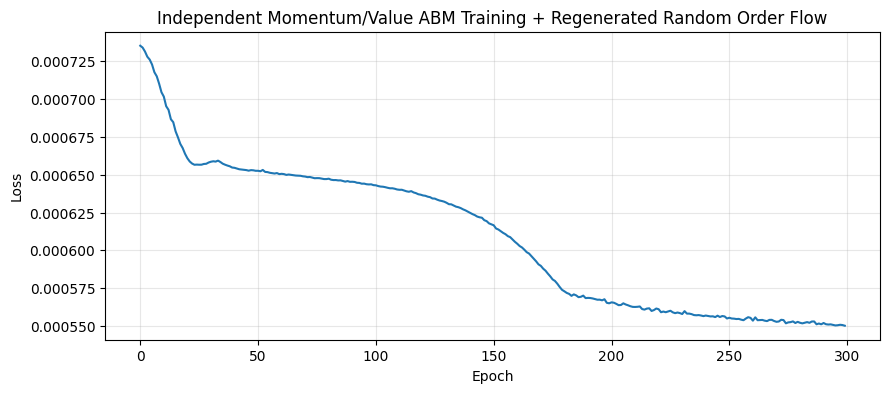

Learned eta: 1.0


In [56]:
# ============================================================
# CELL 7 — Train the 200 momentum/value agents
# ============================================================
#
# IMPORTANT CHANGE:
#
# The 12 thinking agents are NOT used during this training.
#
# Instead, 64 stochastic random-agent orders are generated fresh
# on every epoch. This provides stochastic background order flow
# without allowing the MV agents to memorize one fixed random path.
#
# Final simulation still contains the actual 64 random agents.

def generate_random_training_demand(
    sequence_length,
    n_random=N_RANDOM,
    action_scale=RANDOM_TRAIN_ACTION_SCALE,
    device=DEVICE
):
    # Simulate n_random independent uninformed agents.
    #
    # Each random agent emits a bounded signed order.
    # A new trajectory is generated on every epoch.
    random_actions = torch.tanh(
        torch.randn(
            n_random,
            sequence_length,
            device=device
        )
    ) * action_scale

    # Aggregate exactly like a population-level order flow.
    #
    # We divide by the FULL training population so the random
    # traders do not dominate the 200 learned traders.
    total_population = N_MOMENTUM + N_VALUE + n_random

    return random_actions.sum(dim=0) / total_population


def train_mv_agents(
    df,
    momentum_signal,
    value_signal,
    start_index,
    sequence_length=500,
    epochs=300,
    lr=1e-2,
    warm_up=120
):
    real_prices = torch.tensor(
        df["Close"].to_numpy(dtype=np.float32),
        device=DEVICE
    )

    real_returns = torch.zeros_like(real_prices)
    real_returns[1:] = torch.log(
        (real_prices[1:] + 1e-12) /
        (real_prices[:-1] + 1e-12)
    )

    end_index = min(
        start_index + sequence_length,
        len(df) - 1
    )

    actual_steps = end_index - start_index

    momentum_t = torch.tensor(
        momentum_signal[start_index:end_index],
        dtype=torch.float32,
        device=DEVICE
    )

    value_t = torch.tensor(
        value_signal[start_index:end_index],
        dtype=torch.float32,
        device=DEVICE
    )

    window_prices = real_prices[
        start_index:end_index + 1
    ]

    window_returns = real_returns[
        start_index:end_index
    ]

    model = VectorizedMVABM(
        num_momentum=N_MOMENTUM,
        num_value=N_VALUE
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr
    )

    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()

        # --------------------------------------------------------
        # NEW RANDOM TRAJECTORY EVERY EPOCH
        # --------------------------------------------------------
        random_demand_t = generate_random_training_demand(
            sequence_length=actual_steps,
            n_random=N_RANDOM,
            action_scale=RANDOM_TRAIN_ACTION_SCALE,
            device=DEVICE
        )

        p_sim, r_sim = model(
            initial_price=window_prices[0],
            momentum_signal=momentum_t,
            value_signal=value_t,
            random_demand=random_demand_t,
            historical_prices=window_prices,
            steps=actual_steps,
            warm_up=min(
                warm_up,
                actual_steps
            )
        )

        loss = mv_abm_loss(
            p_sim=p_sim[:-1],
            p_real=window_prices[:-1],
            r_sim=r_sim,
            r_real=window_returns
        )

        if not torch.isfinite(loss):
            print(
                "Non-finite loss at epoch",
                epoch
            )
            break

        loss.backward()

        # --------------------------------------------------------
        # Regularization 1: BPTT gradient clipping
        # --------------------------------------------------------
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=GRAD_CLIP_NORM
        )

        optimizer.step()

        # --------------------------------------------------------
        # Regularization 2: sensitivity + eta clipping
        # --------------------------------------------------------
        with torch.no_grad():
            model.momentum_sensitivity.clamp_(
                -SENSITIVITY_CLIP,
                SENSITIVITY_CLIP
            )

            model.value_sensitivity.clamp_(
                -SENSITIVITY_CLIP,
                SENSITIVITY_CLIP
            )

            model.eta.clamp_(
                1e-5,
                MAX_SIM_ETA
            )

        losses.append(
            float(loss.item())
        )

        if (
            (epoch + 1) %
            max(1, epochs // 10)
            == 0
        ):
            print(
                f"Epoch {epoch+1:04d}/{epochs} | "
                f"Loss={loss.item():.6f} | "
                f"eta={model.eta.item():.6f} | "
                f"random_std={random_demand_t.std().item():.6f}"
            )

    return (
        model,
        losses,
        window_prices.detach().cpu(),
        window_returns.detach().cpu()
    )


# Start once the longest thinking-agent lookback exists.
# The thinking agents are NOT used during MV training, but using
# the same start index keeps the temporal experiment aligned.
START_INDEX = MAX_THINKING_LOOKBACK - 1

mv_model, mv_losses, train_prices, train_returns = train_mv_agents(
    MARKET_DF,
    MOMENTUM_SIGNAL,
    VALUE_SIGNAL,
    start_index=START_INDEX,
    sequence_length=ABM_SEQUENCE_LENGTH,
    epochs=ABM_EPOCHS,
    lr=ABM_LR,
    warm_up=ABM_WARM_UP,
)

plt.figure(figsize=(10, 4))
plt.plot(mv_losses)
plt.title(
    "Independent Momentum/Value ABM Training "
    "+ Regenerated Random Order Flow"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.show()

print("Learned eta:", mv_model.eta.item())


In [57]:
# ============================================================
# CELL 8 — Save each momentum/value agent as its own .pth
# ============================================================

def save_individual_mv_agents(model, out_dir):
    momentum_paths, value_paths = [], []

    with torch.no_grad():
        eta = float(model.eta.item())

        for i in range(model.num_momentum):
            path = os.path.join(out_dir, f"momentum_agent_{i:03d}.pth")
            torch.save({
                "agent_type": "momentum",
                "agent_id": i,
                "sensitivity": float(model.momentum_sensitivity[i].item()),
                "eta": eta,
                "signal_normalization": MOMENTUM_NORM,
            }, path)
            momentum_paths.append(path)

        for i in range(model.num_value):
            path = os.path.join(out_dir, f"value_agent_{i:03d}.pth")
            torch.save({
                "agent_type": "value",
                "agent_id": i,
                "sensitivity": float(model.value_sensitivity[i].item()),
                "eta": eta,
                "signal_normalization": VALUE_NORM,
            }, path)
            value_paths.append(path)

    return momentum_paths, value_paths

MOMENTUM_AGENT_PATHS, VALUE_AGENT_PATHS = save_individual_mv_agents(
    mv_model, MV_AGENT_DIR
)

print("Saved momentum agents:", len(MOMENTUM_AGENT_PATHS))
print("Saved value agents   :", len(VALUE_AGENT_PATHS))
print("Directory:", MV_AGENT_DIR)


Saved momentum agents: 100
Saved value agents   : 100
Directory: C:\Users\user\.vscode\abms\files\checkpoint_6\unified_abm_v2_independent_mv\mv_agents


In [58]:
# ============================================================
# CELL 9 — Load individual momentum/value agents
# ============================================================

class MVAgentNet(nn.Module):
    def __init__(self, sensitivity):
        super().__init__()
        self.sensitivity = nn.Parameter(
            torch.tensor(float(sensitivity)),
            requires_grad=False
        )

    def forward(self, signal):
        return torch.tanh(self.sensitivity * signal)


def load_mv_agents(paths):
    agents = []
    for path in paths:
        ckpt = torch.load(path, map_location="cpu")
        net = MVAgentNet(ckpt["sensitivity"])
        net.eval()
        agents.append({
            "agent_type": ckpt["agent_type"],
            "agent_id": int(ckpt["agent_id"]),
            "model": net,
            "path": path,
            "signal_normalization": ckpt["signal_normalization"],
            "eta": float(ckpt["eta"]),
        })
    return agents

LOADED_MOMENTUM = load_mv_agents(MOMENTUM_AGENT_PATHS)
LOADED_VALUE = load_mv_agents(VALUE_AGENT_PATHS)

print(len(LOADED_MOMENTUM), len(LOADED_VALUE))
print("Example momentum:", LOADED_MOMENTUM[0])
print("Example value:", LOADED_VALUE[0])


100 100
Example momentum: {'agent_type': 'momentum', 'agent_id': 0, 'model': MVAgentNet(), 'path': 'C:\\Users\\user\\.vscode\\abms\\files\\checkpoint_6\\unified_abm_v2_independent_mv\\mv_agents\\momentum_agent_000.pth', 'signal_normalization': {'mean': 0.0005734036094509065, 'std': 0.024026745930314064, 'clip': 4.0}, 'eta': 1.0}
Example value: {'agent_type': 'value', 'agent_id': 0, 'model': MVAgentNet(), 'path': 'C:\\Users\\user\\.vscode\\abms\\files\\checkpoint_6\\unified_abm_v2_independent_mv\\mv_agents\\value_agent_000.pth', 'signal_normalization': {'mean': -0.007671460509300232, 'std': 0.08581142127513885, 'clip': 4.0}, 'eta': 1.0}


In [59]:
# ============================================================
# CELL 9.5 — Limit Order Book (LOB) Engine
# ============================================================
@dataclass
class Order:
    order_id: int
    agent_id: int
    side: str          # 'buy' or 'sell'
    order_type: str    # 'limit' or 'market'
    quantity: int
    price: float
    timestamp: int
    ttl: int = ORDER_TTL

class OrderBook:
    def __init__(self, tick_size=TICK_SIZE, ttl=ORDER_TTL):
        self.tick_size = tick_size
        self.ttl = ttl
        self.bids: List[Order] = []  # sorted descending by price, then ascending timestamp
        self.asks: List[Order] = []  # sorted ascending by price, then ascending timestamp
        self.order_counter = 0
        self.last_trade_price: Optional[float] = None
        
    def round_tick(self, price: float) -> float:
        return round(round(price / self.tick_size) * self.tick_size, 4)
        
    def add_order(self, order: Order):
        if order.quantity <= 0:
            return
        if order.side == 'buy':
            self.bids.append(order)
            # Sort bids: highest price first, earliest timestamp first
            self.bids.sort(key=lambda x: (-x.price, x.timestamp))
        elif order.side == 'sell':
            self.asks.append(order)
            # Sort asks: lowest price first, earliest timestamp first
            self.asks.sort(key=lambda x: (x.price, x.timestamp))
            
    def best_bid(self) -> Optional[float]:
        return self.bids[0].price if self.bids else None
        
    def best_ask(self) -> Optional[float]:
        return self.asks[0].price if self.asks else None
        
    def mid_price(self, fallback_price: float) -> float:
        bb = self.best_bid()
        ba = self.best_ask()
        if bb is not None and ba is not None:
            return self.round_tick(0.5 * (bb + ba))
        if bb is not None:
            return bb
        if ba is not None:
            return ba
        return self.last_trade_price if self.last_trade_price is not None else fallback_price
        
    def spread(self) -> float:
        bb = self.best_bid()
        ba = self.best_ask()
        if bb is not None and ba is not None:
            return max(0.0, ba - bb)
        return 0.0
        
    def expire_orders(self, current_time: int) -> int:
        expired_count = 0
        new_bids = []
        for o in self.bids:
            if (current_time - o.timestamp) >= o.ttl:
                expired_count += 1
            else:
                new_bids.append(o)
        self.bids = new_bids
        
        new_asks = []
        for o in self.asks:
            if (current_time - o.timestamp) >= o.ttl:
                expired_count += 1
            else:
                new_asks.append(o)
        self.asks = new_asks
        return expired_count
        
    def seed_book(self, current_price: float, n_levels: int = BOOK_SEED_ORDERS, width: float = BOOK_SEED_WIDTH, qty_per_level: int = 5):
        """Seed liquidity around current price."""
        for i in range(1, n_levels + 1):
            spread_offset = (i * width / n_levels) * current_price
            bid_p = self.round_tick(max(self.tick_size, current_price - spread_offset))
            ask_p = self.round_tick(current_price + spread_offset)
            
            self.add_order(Order(self.order_counter, -1, 'buy', 'limit', qty_per_level, bid_p, 0, ttl=999999))
            self.order_counter += 1
            self.add_order(Order(self.order_counter, -1, 'sell', 'limit', qty_per_level, ask_p, 0, ttl=999999))
            self.order_counter += 1
            
    def match_orders(self, current_price: float) -> Tuple[List[Dict], Optional[float]]:
        """Price-time priority matching engine. Returns list of executions and last trade price."""
        fills = []
        
        while self.bids and self.asks:
            best_b = self.bids[0]
            best_a = self.asks[0]
            
            # Check match condition
            # If either is market order or bid price >= ask price
            can_match = False
            if best_b.order_type == 'market' or best_a.order_type == 'market':
                can_match = True
            elif best_b.price >= best_a.price:
                can_match = True
                
            if not can_match:
                break
                
            # Determine execution price
            if best_b.order_type == 'limit' and best_a.order_type == 'limit':
                # Earlier order sets the price
                exec_price = best_b.price if best_b.timestamp <= best_a.timestamp else best_a.price
            elif best_b.order_type == 'market' and best_a.order_type == 'limit':
                exec_price = best_a.price
            elif best_b.order_type == 'limit' and best_a.order_type == 'market':
                exec_price = best_b.price
            else:
                exec_price = self.last_trade_price if self.last_trade_price is not None else current_price
                
            exec_qty = min(best_b.quantity, best_a.quantity)
            
            fills.append({
                'buyer_id': best_b.agent_id,
                'seller_id': best_a.agent_id,
                'quantity': exec_qty,
                'price': exec_price,
            })
            
            self.last_trade_price = exec_price
            best_b.quantity -= exec_qty
            best_a.quantity -= exec_qty
            
            if best_b.quantity <= 0:
                self.bids.pop(0)
            if best_a.quantity <= 0:
                self.asks.pop(0)
                
        return fills, self.last_trade_price

print('Limit Order Book Engine registered.')


Limit Order Book Engine registered.


In [60]:
# ============================================================
# CELL 10 — Unified simulation agent with LOB & Calibration support
# ============================================================
class SimAgent:
    def __init__(
        self, agent_id, atype, model=None,
        lookback=1, features_key=None, horizon=None,
        initial_price=None, band=None, checkpoint_id=None
    ):
        self.id = agent_id
        self.type = atype
        self.model = model
        self.lookback = lookback
        self.features_key = features_key
        self.horizon = horizon
        self.band = band
        self.checkpoint_id = checkpoint_id

        # Personality lookup: check (checkpoint_id, band) or agent_id
        params = None
        if checkpoint_id is not None and band is not None:
            params = CALIBRATED_BY_KEY.get((checkpoint_id, band))
        if params is None:
            params = CALIBRATED.get(agent_id)

        if params:
            self.risk = float(params['risk'])
            self.boldness = float(params['boldness'])
            self.range_stock = int(round(params['range_stock']))
            self.fear = float(params['fear'])
        else:
            self.risk = random.uniform(1e-6, 1 - 1e-6)
            self.boldness = random.uniform(0.5, 1.0)
            self.range_stock = random.randint(5, 10)
            if band is not None:
                band_range = next(((lo, hi) for b, lo, hi in FEAR_BANDS if b == band), (0.5, 1.0))
                self.fear = random.uniform(*band_range)
            else:
                self.fear = random.uniform(0.5, 1.0)

        self.cash = STARTING_CASH

        if initial_price is None:
            raise ValueError(
                'initial_price is required for risk-balanced portfolio initialization'
            )

        self.no_stocks = int(
            round(
                (self.risk * self.cash)
                / (initial_price * (1.0 - self.risk))
            )
        )

        self.alive = True
        self.last_action = 0.0
        self.total_trades = 0

    def forecast(self, feat_mats, t, momentum_signal, value_signal):
        if self.type == 'random':
            return float(np.random.randn() * 0.5)

        if self.type == 'momentum':
            s = torch.tensor(float(momentum_signal[t]))
            with torch.no_grad():
                return float(self.model(s).item())

        if self.type == 'value':
            s = torch.tensor(float(value_signal[t]))
            with torch.no_grad():
                return float(self.model(s).item())

        lb = self.lookback
        window = feat_mats[self.features_key][t-lb+1:t+1]
        x = torch.tensor(window, dtype=torch.float32).unsqueeze(0)

        with torch.no_grad():
            raw = float(self.model(x).item())

        return math.tanh(raw * FORECAST_TANH_SCALE)

    def decide_order(self, forecast, price, neighbor_ids, agents_by_id, current_time=0):
        """Decide order action, urgency, order type (market/limit), and limit price."""
        if not self.alive:
            return 0, 'limit', price

        equity = self.cash + self.no_stocks * price
        stock_ratio = (self.no_stocks * price) / (equity + 1e-8)

        # Portfolio pressure
        e = (self.risk - stock_ratio) * E_SCALE

        nei_actions = [
            agents_by_id[n].last_action
            for n in neighbor_ids
            if agents_by_id[n].alive
        ]

        peer = (
            sum(nei_actions) / (len(nei_actions) * self.range_stock)
            if nei_actions else 0.0
        )
        peer *= self.fear

        raw = (forecast + e + peer) * (self.boldness + 0.5)
        action = int(round(self.range_stock * math.tanh(raw)))
        
        u = abs(math.tanh(raw))
        order_type = 'market' if u >= URGENCY_MARKET_THRESHOLD else 'limit'
        
        # Compute limit price based on urgency
        if action > 0:   # Buy order
            limit_price = price * (1.0 - DELTA_MAX * (1.0 - u))
        elif action < 0: # Sell order
            limit_price = price * (1.0 + DELTA_MAX * (1.0 - u))
        else:
            limit_price = price
            
        limit_price = round(round(limit_price / TICK_SIZE) * TICK_SIZE, 4)
        return action, order_type, limit_price

    def decide(self, forecast, price, neighbor_ids, agents_by_id):
        """Backward-compatible decide method for direct demand simulation."""
        action, _, _ = self.decide_order(forecast, price, neighbor_ids, agents_by_id)
        return action

    def submit_order(self, action, order_type, limit_price, price, current_time=0):
        """Construct and return an Order object with inventory/cash validation."""
        if not self.alive or action == 0:
            return None
            
        if action > 0:
            # Check cash capacity
            ref_price = limit_price if order_type == 'limit' else price
            affordable = int(self.cash // max(ref_price, 1e-4))
            qty = min(action, affordable)
            if qty <= 0:
                return None
            return Order(
                order_id=0,
                agent_id=self.id,
                side='buy',
                order_type=order_type,
                quantity=qty,
                price=limit_price,
                timestamp=current_time,
                ttl=ORDER_TTL
            )
        else:
            # Check stock capacity
            qty = min(abs(action), self.no_stocks)
            if qty <= 0:
                return None
            return Order(
                order_id=0,
                agent_id=self.id,
                side='sell',
                order_type=order_type,
                quantity=qty,
                price=limit_price,
                timestamp=current_time,
                ttl=ORDER_TTL
            )

    def apply_fill(self, fill_qty, fill_price):
        """Portfolio mutation on executed order fills."""
        if not self.alive or fill_qty == 0:
            return 0
            
        self.cash -= fill_qty * fill_price
        self.no_stocks += fill_qty
        self.no_stocks = int(self.no_stocks)
        self.last_action = float(fill_qty)
        self.total_trades += 1
        return fill_qty

    def apply_trade(self, action, price):
        """Backward-compatible apply_trade method for direct demand simulation."""
        if not self.alive:
            self.last_action = 0.0
            return 0

        if action > 0:
            affordable = int(self.cash // price)
            action = min(action, affordable)
        elif action < 0:
            action = max(action, -self.no_stocks)

        if action == 0:
            self.last_action = 0.0
            return 0

        self.cash -= action * price
        self.no_stocks += action
        self.no_stocks = int(self.no_stocks)

        self.last_action = float(action)
        self.total_trades += 1
        return action

    def wealth(self, price):
        return self.cash + self.no_stocks * price


In [61]:
# ============================================================
# CELL 11 — Build all 300 agents + fixed neighbor graph
# ============================================================
def build_neighbor_graph(n_agents, choices=(4, 5), seed=42):
    rng = random.Random(seed)
    graph = {}
    for i in range(n_agents):
        k = rng.choice(choices)
        candidates = [j for j in range(n_agents) if j != i]
        graph[i] = rng.sample(candidates, k)
    return graph

def build_all_sim_agents(initial_price):
    agents = []
    next_id = 0

    # 36 thinking agents (12 base x 3 risk bands)
    for a in THINKING_POPULATION:
        agents.append(
            SimAgent(
                agent_id=next_id,
                atype=a['type'],
                model=a['model'],
                lookback=a['lookback'],
                features_key=a['features_key'],
                horizon=a['horizon'],
                initial_price=initial_price,
                band=a.get('band'),
                checkpoint_id=a.get('checkpoint_id'),
            )
        )
        next_id += 1

    # 100 momentum agents
    for a in LOADED_MOMENTUM:
        agents.append(
            SimAgent(
                agent_id=next_id,
                atype='momentum',
                model=a['model'],
                lookback=1,
                features_key=None,
                initial_price=initial_price,
            )
        )
        next_id += 1

    # 100 value agents
    for a in LOADED_VALUE:
        agents.append(
            SimAgent(
                agent_id=next_id,
                atype='value',
                model=a['model'],
                lookback=1,
                features_key=None,
                initial_price=initial_price,
            )
        )
        next_id += 1

    # 64 Random agents
    for _ in range(N_RANDOM):
        agents.append(
            SimAgent(
                agent_id=next_id,
                atype='random',
                model=None,
                lookback=1,
                features_key=None,
                initial_price=initial_price,
            )
        )
        next_id += 1

    return agents

SIM_START = START_INDEX + ABM_SEQUENCE_LENGTH
if SIM_START >= len(MARKET_DF) - 2:
    SIM_START = START_INDEX
# Cap the simulation window at 500 days
SIM_DAYS = min(500, len(MARKET_DF) - SIM_START - 1)

INITIAL_SIM_PRICE = float(MARKET_DF.loc[SIM_START, 'Close'])

SIM_AGENTS = build_all_sim_agents(INITIAL_SIM_PRICE)
AGENTS_BY_ID = {a.id: a for a in SIM_AGENTS}
NEIGHBOR_GRAPH = build_neighbor_graph(len(SIM_AGENTS), NEIGHBOR_CHOICES, SEED)

print('Total agents:', len(SIM_AGENTS))
print(pd.Series([a.type for a in SIM_AGENTS]).value_counts())
print('Initial simulation price:', INITIAL_SIM_PRICE)

# Diagnostic: risk, initial stock ratio, risk band
print('\nInitial portfolio & personality diagnostic (first 36 investors + samples):')
for a in SIM_AGENTS[:36]:
    stock_value = a.no_stocks * INITIAL_SIM_PRICE
    stock_ratio = stock_value / (stock_value + a.cash + 1e-8)
    print(
        f'id={a.id:3d} | type={a.type:8s} | band={str(a.band):5s} | cp={str(a.checkpoint_id):2s} | '
        f'fear={a.fear:.4f} | risk={a.risk:.4f} | stock_ratio={stock_ratio:.4f} | '
        f'boldness={a.boldness:.2f} | range={a.range_stock:2d}'
    )


Total agents: 300
momentum    100
value       100
random       64
cnn           9
gru           9
lstm          9
mlp           9
Name: count, dtype: int64
Initial simulation price: 152.7

Initial portfolio & personality diagnostic (first 36 investors + samples):
id=  0 | type=lstm     | band=low   | cp=0  | fear=0.7866 | risk=0.1892 | stock_ratio=0.1892 | boldness=0.63 | range=10
id=  1 | type=lstm     | band=mid   | cp=0  | fear=0.6191 | risk=0.3075 | stock_ratio=0.3075 | boldness=0.93 | range=10
id=  2 | type=lstm     | band=high  | cp=0  | fear=0.8132 | risk=0.7142 | stock_ratio=0.7142 | boldness=0.75 | range=10
id=  3 | type=lstm     | band=low   | cp=1  | fear=0.5842 | risk=0.0682 | stock_ratio=0.0682 | boldness=0.67 | range= 6
id=  4 | type=lstm     | band=mid   | cp=1  | fear=0.6866 | risk=0.5279 | stock_ratio=0.5279 | boldness=0.91 | range= 7
id=  5 | type=lstm     | band=high  | cp=1  | fear=0.1591 | risk=0.8782 | stock_ratio=0.8782 | boldness=0.63 | range= 8
id=  6 | type=ls

In [73]:
# ============================================================
# CELL 12 — Full population simulation (LOB + Price Rule Dual Mode)
# ============================================================
def run_full_simulation(
    df,
    agents,
    neighbor_graph,
    start_index,
    sim_days=None,
    eta=None,
    dropout_rate=DROPOUT_RATE,
    use_lob=USE_LOB
):
    if eta is None:
        eta = float(mv_model.eta.item()) if 'mv_model' in globals() else 0.05

    if sim_days is None:
        sim_days = len(df) - start_index - 1

    end_index = min(start_index + sim_days, len(df) - 1)

    # Precompute feature matrices for thinking agents ('ts' and 'mlp')
    mats = build_feature_matrices(df)

    initial_portfolio_price = float(df.loc[start_index, 'Close'])
    prices = [initial_portfolio_price]
    real_prices = [initial_portfolio_price]

    records = []
    action_history = []
    wealth_history = []
    alive_history = []

    current_price = initial_portfolio_price

    # Initialize Limit Order Book if enabled
    lob = OrderBook(tick_size=TICK_SIZE, ttl=ORDER_TTL) if use_lob else None
    if use_lob:
        lob.seed_book(current_price, n_levels=BOOK_SEED_ORDERS, width=BOOK_SEED_WIDTH)

    for local_t, t in enumerate(range(start_index, end_index)):
        active = {a.id: (random.random() >= dropout_rate) for a in agents}
        actions = {}
        forecasts = {}
        orders = []

        # 1. Agent Decisions
        for a in agents:
            if not active[a.id] or not a.alive:
                actions[a.id] = 0
                forecasts[a.id] = 0.0
                a.last_action = 0.0
                continue

            f = a.forecast(mats, t, MOMENTUM_SIGNAL, VALUE_SIGNAL)
            forecasts[a.id] = f

            if use_lob:
                act, otype, lprice = a.decide_order(f, current_price, neighbor_graph[a.id], AGENTS_BY_ID, local_t)
                actions[a.id] = act
                order = a.submit_order(act, otype, lprice, current_price, local_t)
                if order is not None:
                    orders.append(order)
            else:
                act = a.decide(f, current_price, neighbor_graph[a.id], AGENTS_BY_ID)
                actions[a.id] = act

        # 2. Execution & Price Update
        filled_actions = {a.id: 0 for a in agents}
        best_b = current_price
        best_a = current_price
        spread = 0.0
        mid_p = current_price
        num_fills = 0

        if use_lob:
            # Expire old orders
            lob.expire_orders(local_t)
            
            # Add new orders
            for o in orders:
                lob.add_order(o)
                
            # Match orders
            fills, last_trade_p = lob.match_orders(current_price)
            num_fills = len(fills)
            
            # Apply fills
            for fill in fills:
                b_id = fill['buyer_id']
                s_id = fill['seller_id']
                q = fill['quantity']
                p = fill['price']
                
                if b_id in AGENTS_BY_ID:
                    filled_actions[b_id] += AGENTS_BY_ID[b_id].apply_fill(q, p)
                if s_id in AGENTS_BY_ID:
                    filled_actions[s_id] += AGENTS_BY_ID[s_id].apply_fill(-q, p)
                    
            best_b = lob.best_bid() or current_price
            best_a = lob.best_ask() or current_price
            spread = lob.spread()
            mid_p = lob.mid_price(current_price)
            
            next_price = last_trade_p if last_trade_p is not None else mid_p
            aggregate_demand = sum(filled_actions.values()) / max(len(agents), 1)
            total_demand = aggregate_demand
            
        else:
            for a in agents:
                filled_actions[a.id] = a.apply_trade(actions[a.id], current_price)

            aggregate_demand = sum(filled_actions.values()) / max(len(agents), 1)
            total_demand = aggregate_demand
            noise = float(np.random.normal(0.0, 0.0015))
            # Random price shock: Uniform(-0.5, 0.5) – adds stochasticity
            price_shock = random.uniform(-1.50, 1.50)
            price_change = float(np.clip(eta * total_demand + noise, -0.10 * max(current_price, 1e-6), 0.10 * max(current_price, 1e-6)))
            next_price = max(current_price + price_change + price_shock, 1e-3)

        log_return = math.log((next_price + 1e-12) / (current_price + 1e-12))

        # 3. Store histories
        action_history.append([filled_actions[a.id] for a in agents])
        alive_history.append([int(a.alive) for a in agents])
        wealth_history.append([a.wealth(next_price) for a in agents])

        type_actions = {}
        for typ in ['lstm', 'gru', 'cnn', 'mlp', 'momentum', 'value', 'random']:
            ids = [a.id for a in agents if a.type == typ]
            type_actions[typ] = float(np.mean([filled_actions[i] for i in ids])) if ids else 0.0

        # Band-specific actions for investors
        band_actions = {}
        for bname in ['low', 'mid', 'high']:
            b_ids = [a.id for a in agents if getattr(a, 'band', None) == bname]
            band_actions[f'mean_action_band_{bname}'] = float(np.mean([filled_actions[i] for i in b_ids])) if b_ids else 0.0

        records.append({
            'local_day': local_t,
            'day_index': t,
            'date': df.loc[t, 'Date'] if 'Date' in df.columns else t,
            'price': next_price,
            'real_price': float(df.loc[t + 1, 'Close']),
            'log_return': log_return,
            'aggregate_action': aggregate_demand,
            'total_demand': total_demand,
            'active_agents': sum(active.values()),
            'alive_agents': sum(a.alive for a in agents),
            'best_bid': best_b,
            'best_ask': best_a,
            'spread': spread,
            'mid_price': mid_p,
            'num_fills': num_fills,
            **{f'mean_action_{k}': v for k, v in type_actions.items()},
            **band_actions,
        })

        current_price = next_price
        prices.append(current_price)
        real_prices.append(float(df.loc[t + 1, 'Close']))

    return {
        'daily': pd.DataFrame(records),
        'prices': np.asarray(prices, dtype=np.float64),
        'real_prices': np.asarray(real_prices, dtype=np.float64),
        'actions': np.asarray(action_history, dtype=np.float32),
        'wealth': np.asarray(wealth_history, dtype=np.float64),
        'alive': np.asarray(alive_history, dtype=np.int8),
        'agents': agents,
        'eta': eta,
        'simulation_start': start_index,
        'lookback': MAX_THINKING_LOOKBACK,
        'use_lob': use_lob,
    }

# ============================================================
# RUN 5 INDEPENDENT ABM SIMULATIONS (each 500 days)
# Each run uses a fresh random seed for dropout masks and
# random-agent behaviour; calibrated eta and sensitivities
# are shared across all runs.
# ============================================================
ALL_RESULTS = []

for sim_idx in range(N_SIMULATIONS):
    run_seed = SEED + sim_idx * 1000
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)

    # Rebuild agents fresh (new personalities / initial positions)
    run_agents = build_all_sim_agents(INITIAL_SIM_PRICE)
    run_graph   = build_neighbor_graph(len(run_agents), NEIGHBOR_CHOICES, run_seed)
    run_agents_by_id = {a.id: a for a in run_agents}

    # Temporarily swap the global AGENTS_BY_ID used inside run_full_simulation
    _g = globals()
    _orig_by_id = _g['AGENTS_BY_ID']
    _g['AGENTS_BY_ID'] = run_agents_by_id

    result = run_full_simulation(
        MARKET_DF,
        run_agents,
        run_graph,
        start_index=SIM_START,
        sim_days=SIM_DAYS,        # capped at 500 days
        dropout_rate=DROPOUT_RATE,
        use_lob=USE_LOB,
    )
    ALL_RESULTS.append(result)

    # Restore global
    _g['AGENTS_BY_ID'] = _orig_by_id

    print(f"Run {sim_idx+1}/{N_SIMULATIONS} | days={len(result['daily'])} | "
          f"eta={result['eta']:.4f} | final_price={result['prices'][-1]:.2f}")

# Use run 0 as primary RESULT for all downstream cells (unchanged behaviour)
RESULT = ALL_RESULTS[0]
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

print()
print('==============================================')
print('FULL ABM SIMULATION (Direct Demand Price Impact Mode)')
print('==============================================')
print('Thinking-agent lookbacks:', AGENT_LOOKBACK)
print('Max lookback:', MAX_THINKING_LOOKBACK, 'days')
print('Lookback window shown in plot: 120 days')
print('Simulation window: 500 days')
print('Number of independent runs:', N_SIMULATIONS)
print('Simulation starts at index:', SIM_START)
print('Simulation start price:', RESULT['prices'][0])
print('Simulation days:', len(RESULT['daily']))
print('Agents:', len(RESULT['agents']))
print('LOB Active:', RESULT['use_lob'])
print('Eta:', RESULT['eta'])
RESULT['daily'].head()


Run 1/5 | days=500 | eta=1.0000 | final_price=116.16
Run 2/5 | days=500 | eta=1.0000 | final_price=106.35
Run 3/5 | days=500 | eta=1.0000 | final_price=128.52
Run 4/5 | days=500 | eta=1.0000 | final_price=106.65
Run 5/5 | days=500 | eta=1.0000 | final_price=118.12

FULL ABM SIMULATION (Direct Demand Price Impact Mode)
Thinking-agent lookbacks: {'lstm': 120, 'gru': 60, 'cnn': 30, 'mlp': 60}
Max lookback: 120 days
Lookback window shown in plot: 120 days
Simulation window: 500 days
Number of independent runs: 5
Simulation starts at index: 619
Simulation start price: 152.7
Simulation days: 500
Agents: 300
LOB Active: False
Eta: 1.0


,local_day,day_index,date,price,real_price,log_return,aggregate_action,total_demand,active_agents,alive_agents,...,mean_action_lstm,mean_action_gru,mean_action_cnn,mean_action_mlp,mean_action_momentum,mean_action_value,mean_action_random,mean_action_band_low,mean_action_band_mid,mean_action_band_high
0,0,619,2013-11-22,155.070199,161.25,0.015403,1.160000,1.160000,149,300,...,0.444444,0.666667,1.444444,1.111111,0.26,2.97,-0.125000,1.500000,0.250000,1.000000
1,1,620,2013-11-25,157.932789,158.05,0.018292,2.203333,2.203333,154,300,...,1.111111,1.000000,3.111111,1.222222,2.61,3.37,0.078125,1.583333,1.833333,1.416667
2,2,621,2013-11-26,160.575419,151.70,0.016594,1.210000,1.210000,158,300,...,1.222222,0.888889,0.888889,1.111111,-0.91,3.99,0.281250,0.583333,1.166667,1.333333
3,3,622,2013-11-27,161.295713,157.05,0.004476,0.650000,0.650000,154,300,...,1.444444,2.000000,2.555556,0.888889,-1.96,3.16,0.203125,1.916667,1.583333,1.666667
4,4,623,2013-11-28,164.019281,157.95,0.016745,1.880000,1.880000,150,300,...,0.333333,0.888889,2.222222,0.333333,2.10,3.08,0.187500,0.500000,0.666667,1.666667


  SIMULATION QUALITY METRICS  (5 independent runs)
 Run        RMSE        MAE%     KS stat      DTW dist
--------------------------------------------------------------
   1      0.3584      21.19%      0.2400       69.0365
   2      0.3856      22.66%      0.2340       84.9567
   3      0.3618      21.90%      0.2360       83.1398
   4      0.4091      23.44%      0.2380       90.0966
   5      0.3786      22.03%      0.2360       73.4030
--------------------------------------------------------------
Mean      0.3787      22.24%      0.2368       80.1265
 Std      0.0183       0.76%      0.0020        7.7461

RMSE      = 0.3787  (log-price domain)
MAE       = 22.24%  (mean absolute % price error)
KS stat   = 0.2368  (return-dist similarity; 0=identical)
DTW dist  = 80.1265  (price-trajectory shape; lower=better)


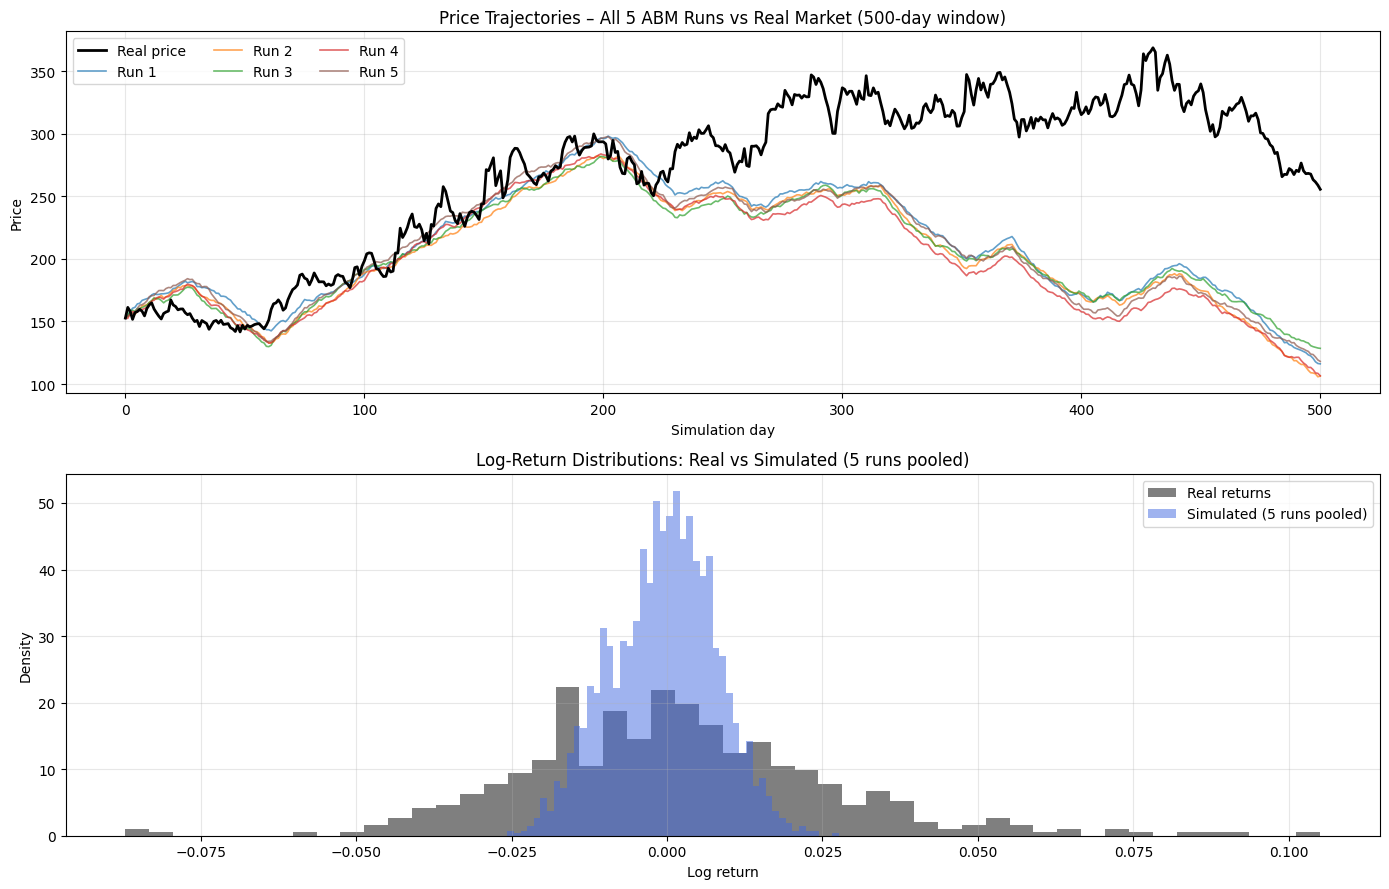

In [74]:
# ============================================================
# CELL 12.5 – Simulation Quality Metrics  (across all 5 runs)
#
#   RMSE     – root mean squared error in log-price space
#   MAE %    – mean absolute percentage price error
#   KS stat  – Kolmogorov-Smirnov statistic on log-return dists
#   DTW dist – Dynamic Time Warping distance on price trajectories
# ============================================================
from scipy.stats import ks_2samp

def dtw_distance(s, t):
    """Simple O(n*m) DTW on 1-D sequences (normalised prices)."""
    n, m = len(s), len(t)
    dtw = np.full((n + 1, m + 1), np.inf)
    dtw[0, 0] = 0.0
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = abs(s[i - 1] - t[j - 1])
            dtw[i, j] = cost + min(dtw[i - 1, j], dtw[i, j - 1], dtw[i - 1, j - 1])
    return dtw[n, m]

print("=" * 62)
print("  SIMULATION QUALITY METRICS  (5 independent runs)")
print("=" * 62)
print(f"{'Run':>4}  {'RMSE':>10}  {'MAE%':>10}  {'KS stat':>10}  {'DTW dist':>12}")
print("-" * 62)

all_rmse, all_mae, all_ks, all_dtw = [], [], [], []

for idx, res in enumerate(ALL_RESULTS):
    sim_p  = res['prices']
    real_p = res['real_prices']
    n = min(len(sim_p), len(real_p))
    sim_p  = sim_p[:n]
    real_p = real_p[:n]

    # RMSE in log-price space
    rmse = float(np.sqrt(np.mean(
        (np.log(sim_p + 1e-12) - np.log(real_p + 1e-12)) ** 2
    )))

    # MAE %
    mae_pct = float(np.mean(np.abs(sim_p - real_p) / (real_p + 1e-8)) * 100)

    # KS statistic on log-returns
    sim_r  = np.diff(np.log(sim_p  + 1e-12))
    real_r = np.diff(np.log(real_p + 1e-12))
    ks_stat, _ = ks_2samp(sim_r, real_r)

    # DTW on normalised prices (subsample to max 200 points for speed)
    step = max(1, n // 200)
    s_norm = (sim_p[::step]  - sim_p[0])  / (sim_p[0]  + 1e-8)
    r_norm = (real_p[::step] - real_p[0]) / (real_p[0] + 1e-8)
    dtw_d  = dtw_distance(s_norm, r_norm)

    all_rmse.append(rmse); all_mae.append(mae_pct)
    all_ks.append(ks_stat); all_dtw.append(dtw_d)

    print(f"{idx+1:>4}  {rmse:>10.4f}  {mae_pct:>9.2f}%  {ks_stat:>10.4f}  {dtw_d:>12.4f}")

print("-" * 62)
print(f"{'Mean':>4}  {np.mean(all_rmse):>10.4f}  {np.mean(all_mae):>9.2f}%  "
      f"{np.mean(all_ks):>10.4f}  {np.mean(all_dtw):>12.4f}")
print(f"{'Std':>4}  {np.std(all_rmse):>10.4f}  {np.std(all_mae):>9.2f}%  "
      f"{np.std(all_ks):>10.4f}  {np.std(all_dtw):>12.4f}")
print("=" * 62)
print()
print(f"RMSE      = {np.mean(all_rmse):.4f}  (log-price domain)")
print(f"MAE       = {np.mean(all_mae):.2f}%  (mean absolute % price error)")
print(f"KS stat   = {np.mean(all_ks):.4f}  (return-dist similarity; 0=identical)")
print(f"DTW dist  = {np.mean(all_dtw):.4f}  (price-trajectory shape; lower=better)")

# --- Fan chart: all 5 runs vs real ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

ax = axes[0]
real_p_base = ALL_RESULTS[0]['real_prices']
ax.plot(real_p_base, color='black', linewidth=2, label='Real price', zorder=5)
colors = plt.cm.tab10(np.linspace(0, 0.5, N_SIMULATIONS))
for idx, res in enumerate(ALL_RESULTS):
    ax.plot(res['prices'], color=colors[idx], alpha=0.7,
            linewidth=1.2, label=f'Run {idx+1}')
ax.set_title('Price Trajectories – All 5 ABM Runs vs Real Market (500-day window)')
ax.set_xlabel('Simulation day'); ax.set_ylabel('Price')
ax.legend(ncol=3); ax.grid(alpha=0.3)

# --- Return-distribution comparison ---
ax2 = axes[1]
real_r_base = np.diff(np.log(ALL_RESULTS[0]['real_prices'] + 1e-12))
pooled_sim_r = np.concatenate([
    np.diff(np.log(r['prices'] + 1e-12)) for r in ALL_RESULTS
])
ax2.hist(real_r_base,   bins=50, alpha=0.5, density=True,
         label='Real returns', color='black')
ax2.hist(pooled_sim_r,  bins=50, alpha=0.5, density=True,
         label='Simulated (5 runs pooled)', color='royalblue')
ax2.set_title('Log-Return Distributions: Real vs Simulated (5 runs pooled)')
ax2.set_xlabel('Log return'); ax2.set_ylabel('Density')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

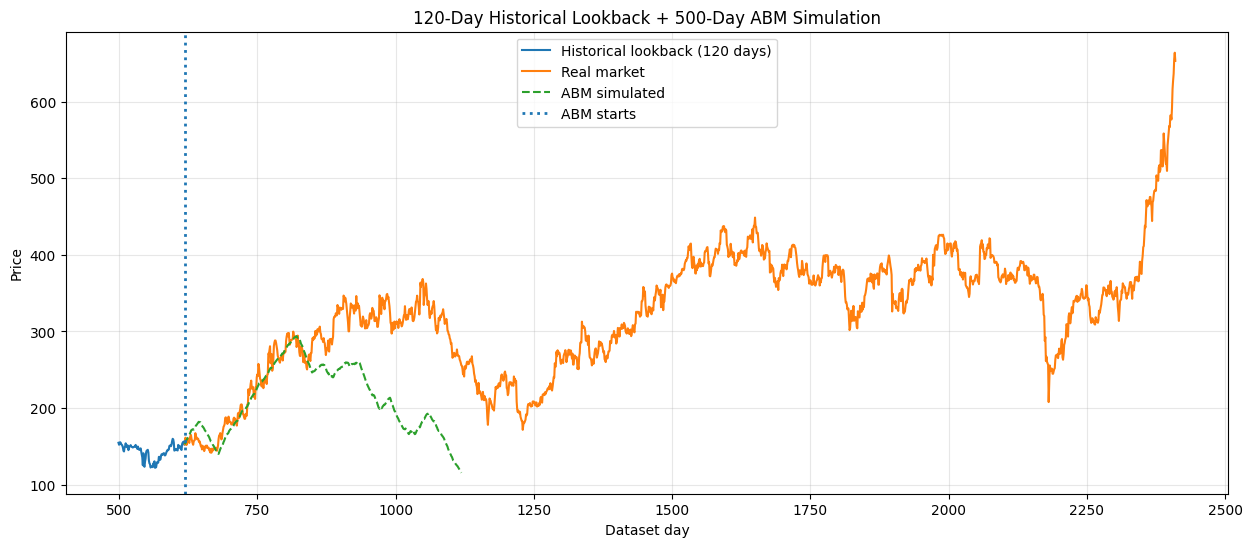

In [64]:
# ============================================================
# CELL 13 — Plot historical lookback + ABM simulation
# ============================================================

sim_prices = RESULT["prices"]
real_prices = RESULT["real_prices"]

# The first simulated point corresponds to SIM_START.
# We want the complete real historical series before it,
# followed by the ABM simulated trajectory.

# Show only the last 120 days of history before simulation start.
LOOKBACK_PLOT_DAYS = 120
history_start = max(0, SIM_START - LOOKBACK_PLOT_DAYS)
history_prices = MARKET_DF["Close"].iloc[
    history_start:SIM_START + 1
].to_numpy()

# ------------------------------------------------------------
# Real prices after simulation starts
# ------------------------------------------------------------

real_future = MARKET_DF["Close"].iloc[
    SIM_START:
].to_numpy()

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(15, 6))

# Historical 120-day lookback
plt.plot(
    np.arange(history_start, history_start + len(history_prices)),
    history_prices,
    label=f"Historical lookback ({LOOKBACK_PLOT_DAYS} days)"
)

# Real market after simulation start
future_x = np.arange(
    SIM_START,
    SIM_START + len(real_future)
)

plt.plot(
    future_x,
    real_future,
    label="Real market"
)

# ABM simulation
sim_x = np.arange(
    SIM_START,
    SIM_START + len(sim_prices)
)

plt.plot(
    sim_x,
    sim_prices,
    linestyle="--",
    label="ABM simulated"
)

# ------------------------------------------------------------
# Mark simulation start
# ------------------------------------------------------------

plt.axvline(
    SIM_START,
    linestyle=":",
    linewidth=2,
    label="ABM starts"
)

plt.title(
    "120-Day Historical Lookback + 500-Day ABM Simulation"
)

plt.xlabel("Dataset day")

plt.ylabel("Price")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

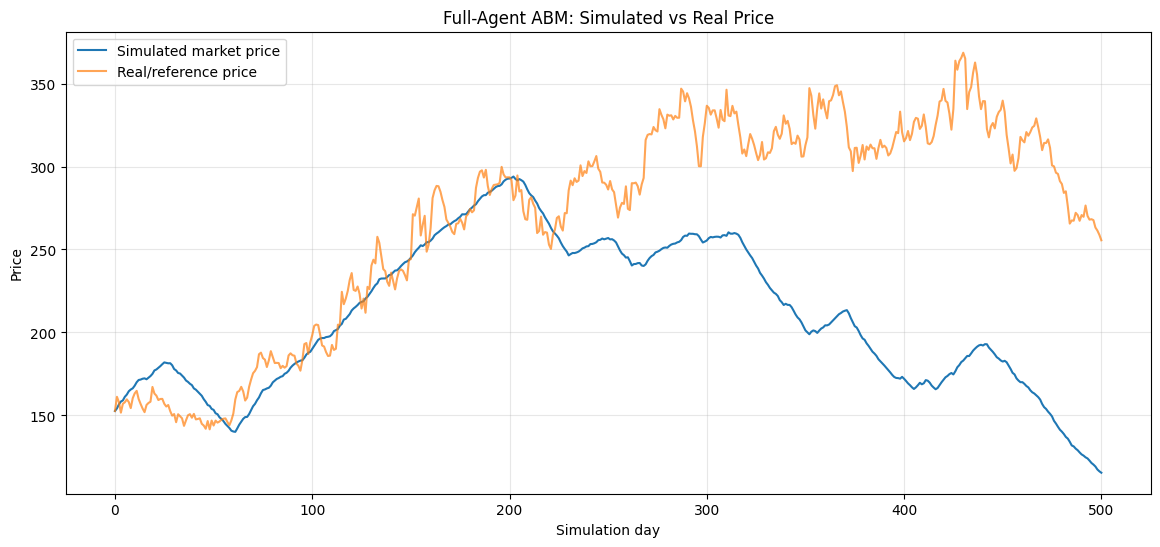

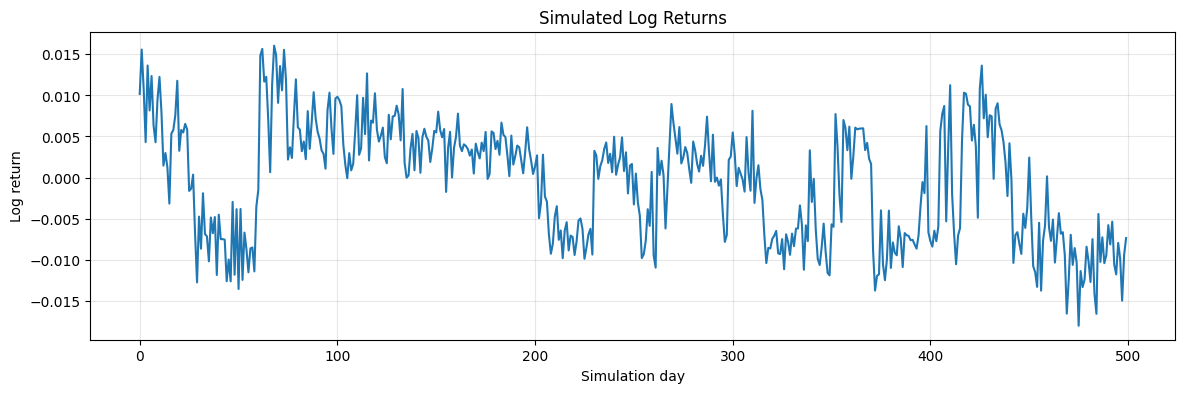

Simulated return mean: -0.0005581306993231801
Simulated return std : 0.007059031374486561


In [65]:
# ============================================================
# CELL 13 — Price and return diagnostics
# ============================================================

daily = RESULT["daily"]

plt.figure(figsize=(14, 6))
plt.plot(RESULT["prices"], label="Simulated market price")
plt.plot(RESULT["real_prices"], label="Real/reference price", alpha=0.7)
plt.title("Full-Agent ABM: Simulated vs Real Price")
plt.xlabel("Simulation day")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(daily["log_return"].to_numpy())
plt.title("Simulated Log Returns")
plt.xlabel("Simulation day")
plt.ylabel("Log return")
plt.grid(alpha=0.3)
plt.show()

print("Simulated return mean:", daily["log_return"].mean())
print("Simulated return std :", daily["log_return"].std())


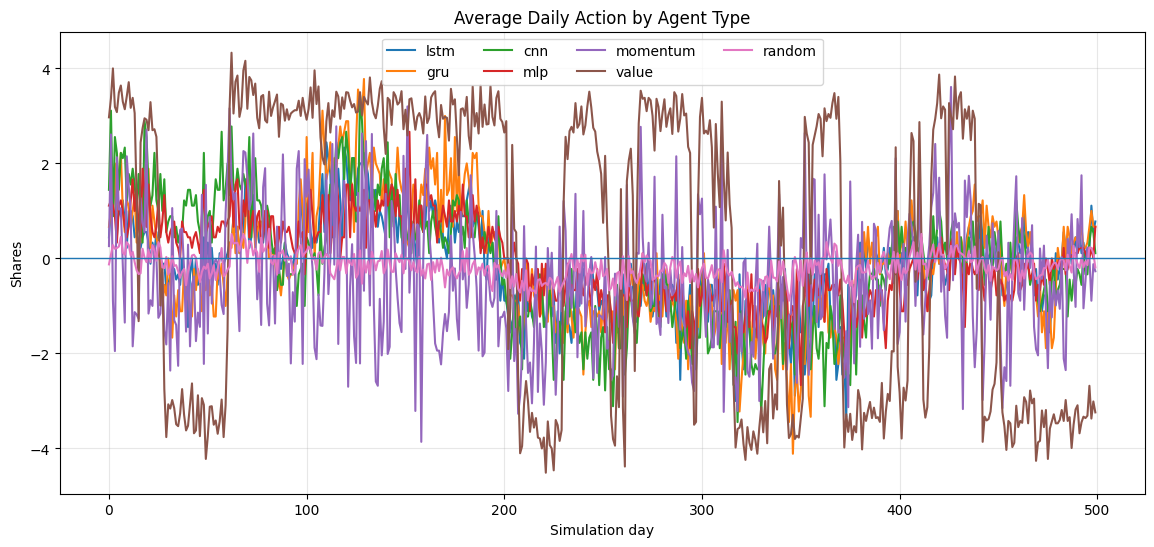

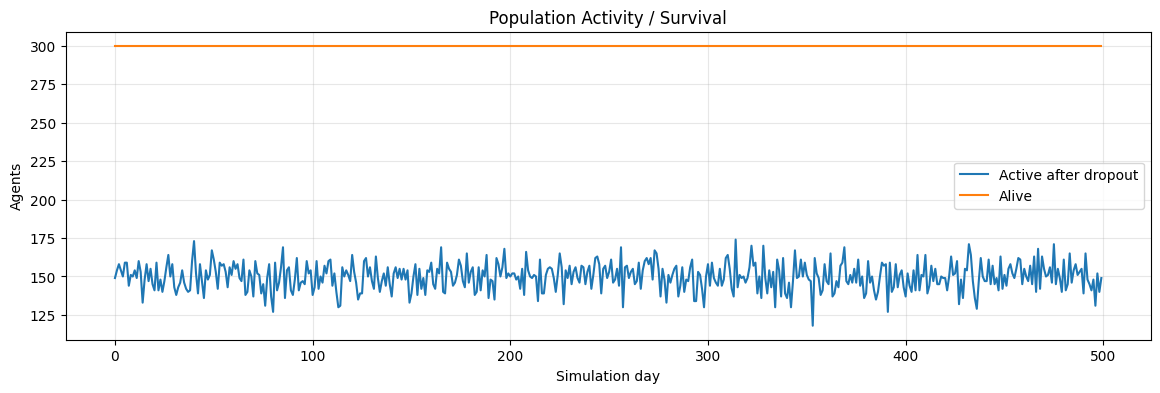

In [66]:
# ============================================================
# CELL 14 — Activity of every agent type
# ============================================================

type_cols = [
    "mean_action_lstm",
    "mean_action_gru",
    "mean_action_cnn",
    "mean_action_mlp",
    "mean_action_momentum",
    "mean_action_value",
    "mean_action_random",
]

plt.figure(figsize=(14, 6))
for c in type_cols:
    plt.plot(daily[c].to_numpy(), label=c.replace("mean_action_", ""))

plt.axhline(0, linewidth=1)
plt.title("Average Daily Action by Agent Type")
plt.xlabel("Simulation day")
plt.ylabel("Shares")
plt.legend(ncol=4)
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(daily["active_agents"], label="Active after dropout")
plt.plot(daily["alive_agents"], label="Alive")
plt.title("Population Activity / Survival")
plt.xlabel("Simulation day")
plt.ylabel("Agents")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


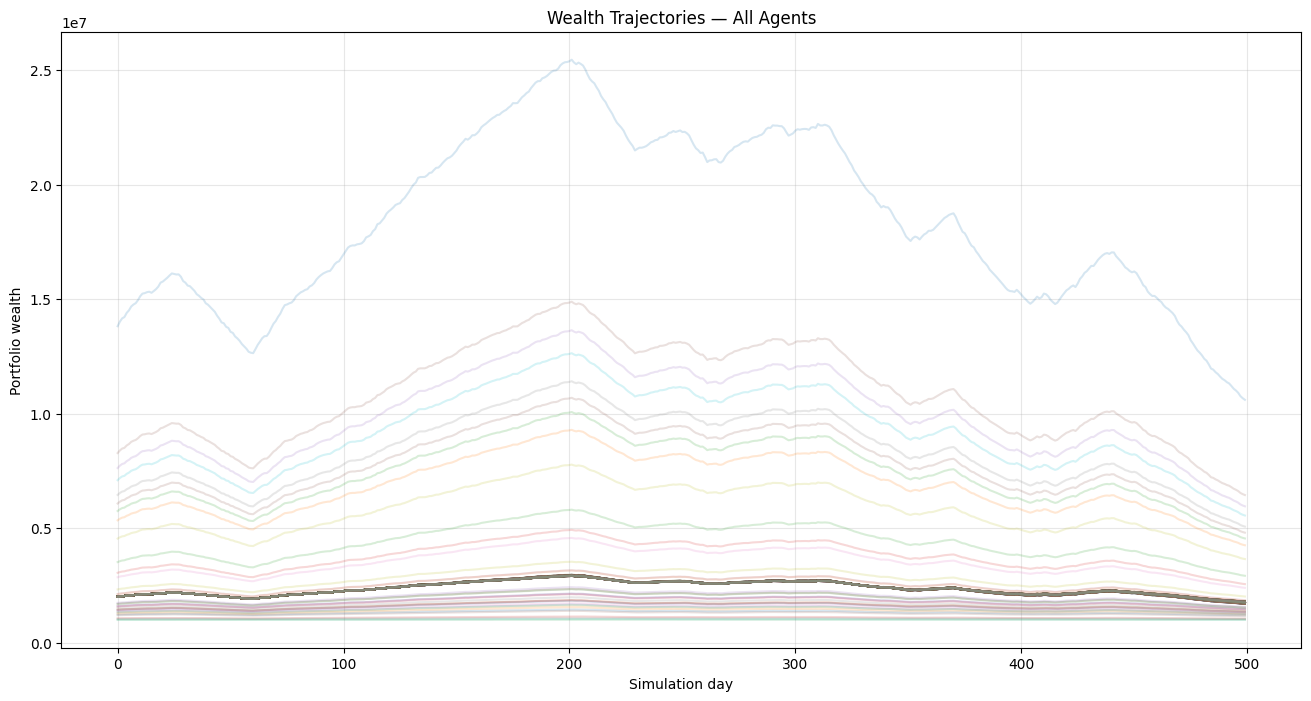

Top 20 agents:


,agent_id,type,horizon,final_wealth,return_pct,trades
0,20,cnn,15.0,1.060648e+07,960.648427,242
1,5,lstm,30.0,6.449761e+06,544.976132,185
2,14,gru,30.0,5.958203e+06,495.820312,201
3,29,mlp,15.0,5.556690e+06,455.668998,223
4,17,gru,45.0,5.072669e+06,407.266945,231
5,35,mlp,45.0,4.807285e+06,380.728528,210
6,32,mlp,30.0,4.554956e+06,355.495602,203
7,11,gru,15.0,4.258822e+06,325.882223,211
8,8,lstm,45.0,3.655449e+06,265.544918,196
9,2,lstm,15.0,2.924907e+06,192.490730,201


In [67]:
# ============================================================
# CELL 15 — Every agent's wealth trajectory
# ============================================================

wealth = RESULT["wealth"]
agent_labels = [
    f"{a.type}_{a.horizon}" if a.horizon is not None
    else f"{a.type}_{a.id}"
    for a in RESULT["agents"]
]

# Plot all 300 agents as requested.
plt.figure(figsize=(16, 8))
for i, label in enumerate(agent_labels):
    plt.plot(wealth[:, i], alpha=0.18)

plt.title("Wealth Trajectories — All Agents")
plt.xlabel("Simulation day")
plt.ylabel("Portfolio wealth")
plt.grid(alpha=0.3)
plt.show()

final_wealth = wealth[-1]
ranking = pd.DataFrame({
    "agent_id": [a.id for a in RESULT["agents"]],
    "type": [a.type for a in RESULT["agents"]],
    "horizon": [a.horizon for a in RESULT["agents"]],
    "final_wealth": final_wealth,
    "return_pct": (final_wealth / STARTING_CASH - 1.0) * 100,
    "trades": [a.total_trades for a in RESULT["agents"]],
})
ranking = ranking.sort_values("final_wealth", ascending=False).reset_index(drop=True)

print("Top 20 agents:")
display(ranking.head(20))


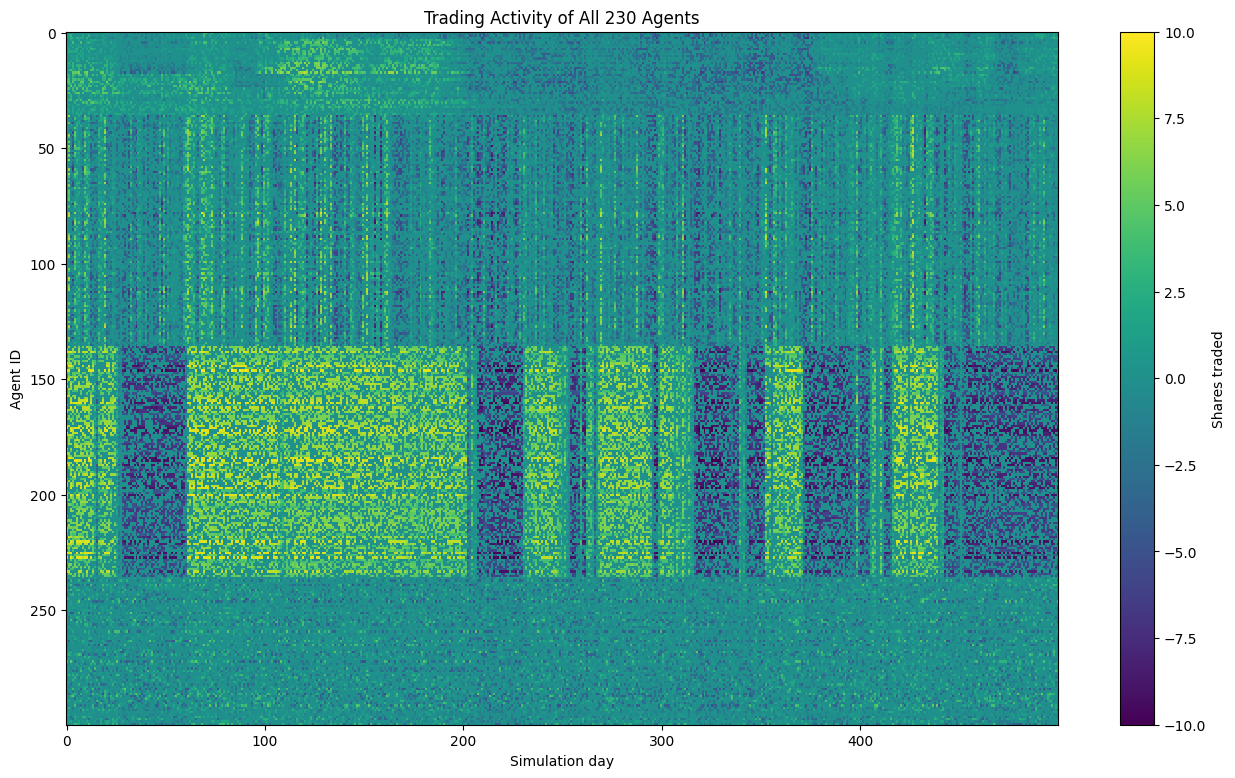

In [68]:
# ============================================================
# CELL 16 — Agent-level action heatmap
# ============================================================

plt.figure(figsize=(16, 9))
plt.imshow(
    RESULT["actions"].T,
    aspect="auto",
    interpolation="nearest"
)
plt.colorbar(label="Shares traded")
plt.xlabel("Simulation day")
plt.ylabel("Agent ID")
plt.title("Trading Activity of All 230 Agents")
plt.show()


,agents,mean_final_wealth,median_final_wealth,mean_return_pct,median_return_pct,mean_trades
type,,,,,,
mlp,9,2.666472e+06,1.844992e+06,166.647224,84.499220,211.333333
cnn,9,2.649222e+06,1.535404e+06,164.922179,53.540380,217.555556
gru,9,2.540770e+06,1.463975e+06,154.076968,46.397534,212.555556
lstm,9,2.356113e+06,1.401155e+06,135.611292,40.115503,199.444444
momentum,100,1.786298e+06,1.786066e+06,78.629804,78.606626,220.640000
random,64,1.767414e+06,1.766512e+06,76.741425,76.651181,202.937500
value,100,1.720723e+06,1.721737e+06,72.072322,72.173743,249.400000


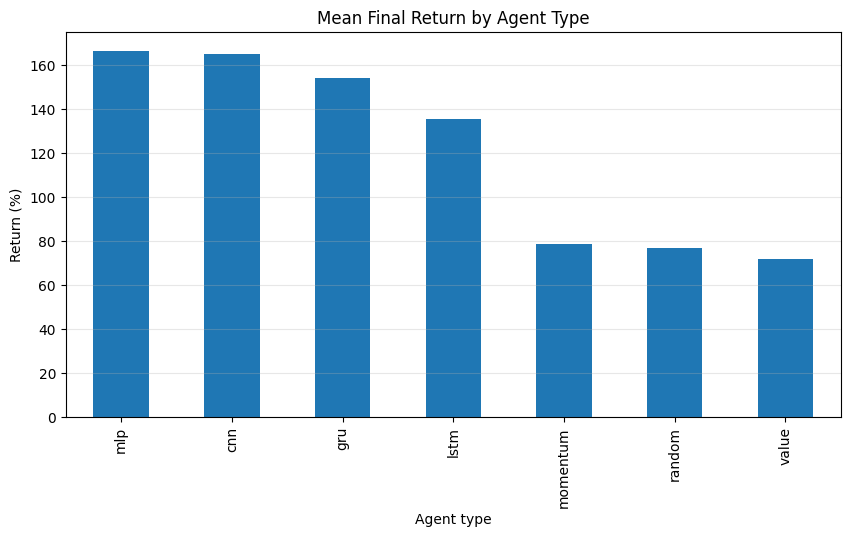

In [69]:
# ============================================================
# CELL 17 — Compare final performance by agent family
# ============================================================

summary = (
    ranking
    .groupby("type")
    .agg(
        agents=("agent_id", "count"),
        mean_final_wealth=("final_wealth", "mean"),
        median_final_wealth=("final_wealth", "median"),
        mean_return_pct=("return_pct", "mean"),
        median_return_pct=("return_pct", "median"),
        mean_trades=("trades", "mean"),
    )
    .sort_values("mean_return_pct", ascending=False)
)

display(summary)

plt.figure(figsize=(10, 5))
summary["mean_return_pct"].plot(kind="bar")
plt.title("Mean Final Return by Agent Type")
plt.ylabel("Return (%)")
plt.xlabel("Agent type")
plt.grid(axis="y", alpha=0.3)
plt.show()


=== INVESTOR RISK BAND PERFORMANCE COMPARISON ===


risk                          fear                     return_pct  \
          mean       min       max      mean       min       max       mean   
band                                                                          
high  0.804683  0.648275  0.926951  0.503851  0.159080  0.876368 -20.123479   
low   0.172858  0.008408  0.304726  0.540227  0.290365  0.914409  -3.443421   
mid   0.409863  0.302473  0.568367  0.445829  0.148373  0.796164  -9.224122   

                                      final_wealth                  id  
           std        min        max          mean        median count  
band                                                                    
high  2.415063 -23.248233 -16.131799  4.900629e+06  4.681121e+06    12  
low   2.538046  -6.730718   0.297050  1.184952e+06  1.219378e+06    12  
mid   2.665076 -13.300744  -5.269223  1.573852e+06  1.504427e+06    12

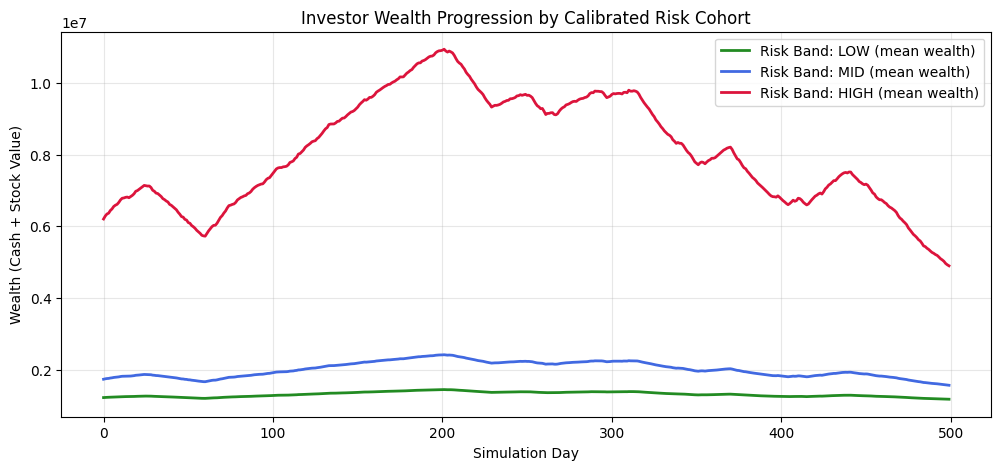

In [70]:
# ============================================================
# CELL 17.5 — Investor Cohort Analysis by Risk Band (low/mid/high)
# ============================================================
wealth = RESULT['wealth']
final_wealth = wealth[-1]

investor_records = []
for a in SIM_AGENTS:
    if getattr(a, 'band', None) is not None:
        investor_records.append({
            'id': a.id,
            'type': a.type,
            'band': a.band,
            'checkpoint_id': a.checkpoint_id,
            'risk': a.risk,
            'fear': a.fear,
            'boldness': a.boldness,
            'range_stock': a.range_stock,
            'initial_wealth': wealth[0, a.id],
            'final_wealth': final_wealth[a.id],
            'return_pct': ((final_wealth[a.id] - wealth[0, a.id]) / wealth[0, a.id]) * 100.0,
        })

investor_df = pd.DataFrame(investor_records)
print('=== INVESTOR RISK BAND PERFORMANCE COMPARISON ===')
band_summary = investor_df.groupby('band').agg({
    'risk': ['mean', 'min', 'max'],
    'fear': ['mean', 'min', 'max'],
    'return_pct': ['mean', 'std', 'min', 'max'],
    'final_wealth': ['mean', 'median'],
    'id': 'count'
})
display(band_summary)

# Plot wealth progression by risk band
plt.figure(figsize=(12, 5))
for bname, col in [('low', 'forestgreen'), ('mid', 'royalblue'), ('high', 'crimson')]:
    b_ids = [a.id for a in SIM_AGENTS if getattr(a, 'band', None) == bname]
    if b_ids:
        mean_w = wealth[:, b_ids].mean(axis=1)
        plt.plot(mean_w, label=f'Risk Band: {bname.upper()} (mean wealth)', color=col, linewidth=2)

plt.title('Investor Wealth Progression by Calibrated Risk Cohort')
plt.xlabel('Simulation Day')
plt.ylabel('Wealth (Cash + Stock Value)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [71]:
# ============================================================
# CELL 18 — Save simulation outputs
# ============================================================

daily.to_csv(
    os.path.join(OUTPUT_DIR, "simulation_daily.csv"),
    index=False
)

ranking.to_csv(
    os.path.join(OUTPUT_DIR, "agent_final_ranking.csv"),
    index=False
)

np.save(
    os.path.join(OUTPUT_DIR, "all_agent_actions.npy"),
    RESULT["actions"]
)

np.save(
    os.path.join(OUTPUT_DIR, "all_agent_wealth.npy"),
    RESULT["wealth"]
)

torch.save(
    mv_model.state_dict(),
    os.path.join(OUTPUT_DIR, "mv_abm_vectorized_state.pt")
)

print("Saved:")
for name in [
    "simulation_daily.csv",
    "agent_final_ranking.csv",
    "all_agent_actions.npy",
    "all_agent_wealth.npy",
    "mv_abm_vectorized_state.pt",
]:
    print(" -", os.path.join(OUTPUT_DIR, name))

print("\nIndividual .pth agents:")
print(" -", MV_AGENT_DIR)


Saved:
 - C:\Users\user\.vscode\abms\files\checkpoint_6\unified_abm_v2_independent_mv\simulation_daily.csv
 - C:\Users\user\.vscode\abms\files\checkpoint_6\unified_abm_v2_independent_mv\agent_final_ranking.csv
 - C:\Users\user\.vscode\abms\files\checkpoint_6\unified_abm_v2_independent_mv\all_agent_actions.npy
 - C:\Users\user\.vscode\abms\files\checkpoint_6\unified_abm_v2_independent_mv\all_agent_wealth.npy
 - C:\Users\user\.vscode\abms\files\checkpoint_6\unified_abm_v2_independent_mv\mv_abm_vectorized_state.pt

Individual .pth agents:
 - C:\Users\user\.vscode\abms\files\checkpoint_6\unified_abm_v2_independent_mv\mv_agents


In [72]:
# ============================================================
# VALIDATION — Confirm the intended training/simulation split
# ============================================================

print("=== TRAINING / SIMULATION DESIGN CHECK ===")
print("Thinking agents used in MV training: NO")
print("Random agents represented during MV training: YES")
print("Random trajectories regenerated each epoch: YES")
print("Thinking agents used in final simulation: YES")
print("Aggregate thinking demand double-counted in simulation: NO")
print("Fear/herding in final simulation: YES")
print("Risk-balanced initialization: ", INITIALIZE_AT_RISK)
print("Total final agents:", len(SIM_AGENTS))
print("Expected final agents:", N_INVESTORS + N_MOMENTUM + N_VALUE + N_RANDOM)
print("Learned eta:", float(mv_model.eta.item()))


=== TRAINING / SIMULATION DESIGN CHECK ===
Thinking agents used in MV training: NO
Random agents represented during MV training: YES
Random trajectories regenerated each epoch: YES
Thinking agents used in final simulation: YES
Aggregate thinking demand double-counted in simulation: NO
Fear/herding in final simulation: YES
Risk-balanced initialization:  True
Total final agents: 300
Expected final agents: 300
Learned eta: 1.0


## What this notebook now gives you

- **12 frozen thinking agents** loaded from `checkpoint_6`.
- **100 independently learned momentum sensitivities**.
- **100 independently learned value sensitivities**.
- Each momentum/value agent is stored as a separate `.pth`.
- **64 random agents** in the final population.
- A single simulation containing **300 agents**.
- Test-1 risk-balanced portfolio initialization.
- Fear/herding remains enabled.
- **MV training is independent of thinking-agent demand.**
- **64 stochastic random agents are represented during MV training as regenerated background order flow.**
- Random training demand is regenerated every epoch to reduce memorization of a fixed noise trajectory.
- The 12 thinking agents are introduced only during the final full-agent simulation.
- Thinking-agent demand is not double-counted: their individual actions are the simulation contribution.
- Additive market-price equation:

  `P(t+1) = P(t) + eta * D(t)`

- Portfolio state: cash, holdings, wealth and survival.
- Personality: risk, boldness, fear and trading range.
- Neighbor influence and daily dropout.
- Agent-level action and wealth trajectories.
- Type-level performance comparison.
- CSV/NumPy outputs for later analysis.

### Training architecture

The training is deliberately separated into two stages:

**Stage 1 — Frozen thinking agents**

The existing 12 neural forecasters are loaded from `checkpoint_6` and remain frozen.

**Stage 2 — Momentum/value ABM**

Only the 100 momentum + 100 value sensitivities are optimized. Thinking-agent demand is excluded from this optimization.

The 64 random traders are represented during training by fresh stochastic order flow generated independently on every epoch.

**Stage 3 — Full market simulation**

The 36 thinking + 100 momentum + 100 value + 64 random (300 total) agents interact together. Their individual orders are aggregated into the market demand.

This prevents the MV agents from learning to compensate for the thinking-agent ensemble and prevents the thinking-agent demand from being counted twice during the final simulation.
